In [238]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
from datetime import datetime

from sklearn.preprocessing import StandardScaler

In [96]:
# file:///D:/Python_Code/Project_DS108/Paper/1-s2.0-S2772415825000100-main.pdf

In [97]:
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

# Description
- Market_Value (target): Giá trị cầu thủ chuyển nhượng 
- Player : Tên cầu thủ
- CLB : Câu lạc bộ đang thi đấu
- League : Giải đấu đang thi đấu
- Age : Độ tuổi 
- National : Quốc tịch
- Height : Chiều cao 
- Main_position : Vị trí thi đấu chính trên sân 
- Foot : Chân thuận 
- Months_left : Số tháng còn lại trong hợp đồng
- Start_app : Số lần đá chính
- Sub_app : Số lần vào sân từ băng ghế dự bị 
- Mins : Tổng số phút thi đấu 
- Goals : Số lượng bàn thắng 
- Assists : Tổng số đường kiến tạo
- Yel : Tổng số thẻ vàng nhận
- Red : Tổng số thẻ đỏ nhận 
- SpG : Tổng số cú sút trung bình 
- PS% : Tỉ lệ thành công của các đường truyền 
- AerialsWon : 
- MotM : Số lần được chọn là cầu thủ xuất sắc nhất trận đấu 
- Rating : Điểm trung bình được các nhà báo thể thao đánh giá sau trận

 

In [202]:
data = pd.read_csv('Final_Data.csv').drop (['Unnamed: 0.1', 'Unnamed: 0','CLB'], axis=1)
data

,Club,Age,Height,National,Positions,TotAD,WonAD,LostAD,CrAss,CorAss,ThrbAss,FreAss,ThrInAss,OthAss,TotAss,BlkSh,BlkCr,BlkPs,YelC,RedC,TotClr,UnDrib,SucDrib,TotDrib,Fouled,...,OOBSav,TotSh,OOBSh,SYBSh,PASh,TotTkl,DribPast,TotAttTkl,Player,Apps,Mins,Goals,Assists,Yel,Red,SpG,PS%,AerialsWon,MotM,Rating,League,Main_position,Foot,Contract,Market_Value
0,St. Pauli,21 years old (05-01-2004),"1,85m",Gambia,Forward,0.9,-,0.9,-,-,-,-,-,-,-,-,-,0.3,0.1,-,0.1,-,-,-,0.4,...,-,-,-,-,-,0.4,0.1,0.6,Abdoulie Ceesay,0(7),55,-,-,1,-,-,57.1,-,-,6.04,Bundesliga,Centre-Forward,NaN,-,€500k
1,St. Pauli,29 years old (25-09-1995),"1,85m",Poland,"Defender (Centre, Right)",1.1,0.9,0.2,-,-,-,-,-,-,-,0.1,-,0.4,0.1,0.1,1.6,0.1,0.1,0.1,0.1,...,-,0.4,-,-,0.4,1.4,0.4,1.7,Adam Dzwigala,2(12),305,-,-,2,1,0.4,82.7,0.9,-,6.21,Bundesliga,Centre-Back,right,-,€600k
2,Hoffenheim,22 years old (25-07-2002),"1,88m",Czech Republic,"Attacking Midfielder (Centre, Left, Right), Fo...",3,1.5,1.5,-,-,-,-,-,-,0.1,-,0.1,0.5,0.1,-,0.8,1.1,1.2,2.3,1.2,...,-,2.2,0.8,0.1,1.3,0.8,0.4,1.2,Adam Hlozek,19(5),1619,7,2,2,-,2.2,70.4,1.5,3,6.84,Bundesliga,Second Striker,right,"Jun 30, 2029",€18.00m
3,FC Heidenheim,27 years old (09-06-1997),"1,86m",Germany,"Attacking Midfielder (Centre, Right)",1.4,0.9,0.6,-,-,-,-,-,-,-,0.1,-,0.9,-,-,0.6,1,1.2,2.2,0.3,...,-,1.1,0.4,0.1,0.5,1.2,0.8,1.9,Adrian Beck,15(14),1383,2,1,1,-,1.1,81.9,0.9,-,6.55,Bundesliga,Attacking Midfield,right,"Jun 30, 2028",€2.00m
4,Borussia M.Gladbach,32 years old (10-03-1993),"1,81m",France,"Attacking Midfielder (Centre, Left, Right), Fo...",1.7,0.5,1.1,-,-,-,-,-,0.1,0.1,-,-,0.4,0.1,-,0.3,0.9,0.6,1.5,1.2,...,-,1.4,0.3,0.2,1,0.3,0.3,0.5,Alassane Plea,23(5),1812,11,4,3,-,1.4,75.6,0.5,2,6.76,Bundesliga,Centre-Forward,right,"Jun 30, 2026",€6.00m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2344,Juventus,27 years old (06-04-1998),"1,80m",Argentina,"Midfielder (Centre, Left, Right), Forward",4.3,2.4,1.9,-,-,-,-,-,0.1,0.1,0.2,-,0.5,-,-,1.1,1.5,0.7,2.2,1.5,...,-,1.7,0.5,0.2,1,1,0.6,1.6,Nicolas Gonzalez,19(3),1471,2,2,1,-,1.7,76.6,2.4,-,6.81,SerieA,Right Winger,left,"Jun 30, 2025",€28.00m
2345,Como,25 years old (02-08-1999),"1,86m",Greece,"Attacking Midfielder (Right), Forward",2.2,0.7,1.6,-,-,-,-,-,-,-,-,-,0.3,0.1,-,0.2,0.3,0.4,0.8,1.3,...,-,1,0.1,0.2,0.7,0.3,0.2,0.6,Tasos Douvikas,3(6),369,2,-,1,-,1,77.3,0.7,-,6.39,SerieA,Centre-Forward,right,"Jun 30, 2029",€8.00m
2346,Lecce,24 years old (28-09-2000),"1,87m",Iceland,Attacking Midfielder (Centre),1.8,0.9,0.9,0.2,0.1,-,0.1,-,0.1,0.2,0.1,0.3,0.2,-,-,0.3,0.4,0.4,0.7,0.6,...,-,0.8,0.4,0.1,0.4,0.6,0.2,0.8,Thorir Helgason,11(6),946,-,4,-,-,0.8,71.8,0.9,-,6.49,SerieA,Central Midfield,right,"Jun 30, 2026",€2.50m
2347,Lazio,26 years old (03-10-1998),"1,78m",Argentina,"Attacking Midfielder (Right), Forward",4.6,2.4,2.3,-,-,-,-,-,0.1,0.1,0.1,-,0.6,0.3,-,0.8,0.8,0.6,1.3,1.5,...,-,3.7,1.1,0.3,2.3,0.4,0.3,0.8,Valentin Castellanos,24(1),2036,10,3,7,1,3.7,69.9,2.4,4,7.08,SerieA,Centre-Forward,right,"Jun 30, 2028",€25.00m


# Format Normalization 

## Các thuộc tính cần phải xử lý trích xuất thông tin phù hợp 
    + Age 21 years old (05-01-2004) -> 21
    + Height 1,85m -> 185cm 
    + Contract (Thời hạn kết thúc hợp đồng) Jun 30, 2029 => Chuyển về thành thời gian còn lại trong hợp đồng (tháng)
    + Market Value : €500k -> 500000 hoặc €8.00m -> 8000000
    + Apps 0(7) -> chia ra 0 trận thi đấu chính thức và 7 trận thi đấu từ băng ghế dự bị

### Age: 21 years old (05-01-2004) -> 21

In [203]:
data['Age'] = data['Age'].astype(str)
for i in range(len(data['Age'])):
    if data['Age'][i] == 'nan':
        data['Age'][i] = np.nan
        continue
    x = data['Age'][i]
    new_age = x[0] + x[1]
    new_age = int(new_age)
    data['Age'][i] = new_age
    #print(i, new_age, type(new_age))
data['Age'].unique()

array([21, 29, 22, 27, 32, 20, 26, 34, 28, 23, 18, 24, 35, 25, 33, 39, 19,
       31, 30, 38, 36, 37, 17, 40, nan, 41, 16, 42], dtype=object)

### Height:  1,85m -> 185cm 

In [204]:
data['Height'].unique()

array(['1,85m', '1,88m', '1,86m', '1,81m', '1,73m', '1,95m', '1,93m',
       '1,80m', '1,90m', '1,76m', '1,87m', '1,83m', '1,78m', '1,92m',
       '1,89m', '1,77m', '1,84m', '1,94m', '1,75m', '1,70m', '1,74m',
       '1,91m', '1,97m', '-', '1,96m', '1,72m', '1,79m', '1,82m', '1,98m',
       '1,67m', '1,71m', '1,69m', '1,68m', '2,02m', '2,01m', '1,99m',
       '1,63m', '1,64m', '1,65m', '1,66m', '2,00m', '2,06m'], dtype=object)

In [205]:
data['Height'] = data['Height'].astype(str)
for i in range(len(data['Height'])):
    if data['Height'][i] == '-':
        data['Height'][i] = np.nan
        continue
    x = data['Height'][i]
    new_height = x[0] + x[2] + x[3]
    new_height = int(new_height)
    data['Height'][i] = new_height
    #print(i, new_height)
data['Height'].unique()

array([185, 188, 186, 181, 173, 195, 193, 180, 190, 176, 187, 183, 178,
       192, 189, 177, 184, 194, 175, 170, 174, 191, 197, nan, 196, 172,
       179, 182, 198, 167, 171, 169, 168, 202, 201, 199, 163, 164, 165,
       166, 200, 206], dtype=object)

### Market Value 

In [206]:
data['Market_Value'].unique()

array(['€500k', '€600k', '€18.00m', '€2.00m', '€6.00m', '€20.00m',
       '€50.00m', '€1.50m', '€800k', '€12.00m', '€6.50m', '€700k',
       '€7.00m', '€1.00m', '€7.50m', '€22.00m', '€3.00m', '€300k',
       '€16.00m', '€2.50m', '€4.00m', '€5.00m', '€38.00m', '€10.00m',
       '€14.00m', '€28.00m', '€24.00m', '€9.00m', '€17.00m', '€65.00m',
       '€5.50m', '€15.00m', '€750k', '€13.00m', '€25k', '€25.00m',
       '€550k', '€3.50m', '€40.00m', '€35.00m', '€8.00m', '€1.20m',
       '€140.00m', '€4.50m', '€90.00m', '€30.00m', '€55.00m', '€1.80m',
       '€8.50m', '€1.30m', '€900k', '€200k', '€60.00m', '€27.00m',
       '€2.80m', '€80.00m', '€45.00m', '€175k', '€400k', '€350k',
       '€70.00m', '€3.20m', '€32.00m', '€100.00m', '€11.00m', '€150.00m',
       '€130.00m', '€42.00m', '€110.00m', '€75.00m', '€200.00m',
       '€23.00m', '€85.00m', '€3.80m', '€100k', '€1.40m', '€2.20m',
       '€180.00m', '€170.00m', '€2.30m', '€120.00m', '€150k', '€1.60m',
       '€3.40m', '€12.50m', '€1.10m', 

In [207]:
def convert_to_int(euro_str):
    euro_str = euro_str.replace('€', '').lower()
    if euro_str.endswith('m'):
        return int(float(euro_str[:-1]) * 1_000_000)
    elif euro_str.endswith('k'):
        return int(float(euro_str[:-1]) * 1_000)
    else:
        return int(float(euro_str))  # fallback, in case no suffix
    
for i in range(len(data['Market_Value'])):
    data['Market_Value'][i] = convert_to_int(data['Market_Value'][i])

data['Market_Value']= data['Market_Value'].astype(int)
data['Market_Value'].unique()

array([   500000,    600000,  18000000,   2000000,   6000000,  20000000,
        50000000,   1500000,    800000,  12000000,   6500000,    700000,
         7000000,   1000000,   7500000,  22000000,   3000000,    300000,
        16000000,   2500000,   4000000,   5000000,  38000000,  10000000,
        14000000,  28000000,  24000000,   9000000,  17000000,  65000000,
         5500000,  15000000,    750000,  13000000,     25000,  25000000,
          550000,   3500000,  40000000,  35000000,   8000000,   1200000,
       140000000,   4500000,  90000000,  30000000,  55000000,   1800000,
         8500000,   1300000,    900000,    200000,  60000000,  27000000,
         2800000,  80000000,  45000000,    175000,    400000,    350000,
        70000000,   3200000,  32000000, 100000000,  11000000, 150000000,
       130000000,  42000000, 110000000,  75000000, 200000000,  23000000,
        85000000,   3800000,    100000,   1400000,   2200000, 180000000,
       170000000,   2300000, 120000000,    150000, 

# Feature Extraction (1)

### Contract

In [208]:
data['Contract'].unique()

array(['-', 'Jun 30, 2029', 'Jun 30, 2028', 'Jun 30, 2026',
       'Jun 30, 2027', 'Jun 30, 2030', 'Jun 30, 2025', 'Jul 31, 2025',
       'Jun 30, 2031', 'May 31, 2025', 'Jun 30, 2033', 'Jun 30, 2032',
       'Jun 30, 2034', 'May 30, 2029', 'Jun 3, 2027'], dtype=object)

In [213]:
today = datetime(2025, 5, 22)

def months_remaining(date_str):
    if date_str == '-':
        return np.nan 
    try:
        date = datetime.strptime(date_str, '%b %d, %Y')
        return (date.year - today.year) * 12 + (date.month - today.month)
    except:
        return np.nan


months_left = np.array([months_remaining(d) for d in data['Contract']], dtype=float)

data['Months_left'] = months_left
data['Months_left']

0        NaN
1        NaN
2       49.0
3       37.0
4       13.0
        ... 
2344     1.0
2345    49.0
2346    13.0
2347    37.0
2348    13.0
Name: Months_left, Length: 2349, dtype: float64

In [214]:
data['Contract'].value_counts()

Contract
Jun 30, 2025    545
Jun 30, 2026    448
Jun 30, 2027    448
Jun 30, 2028    444
Jun 30, 2029    281
-               100
Jun 30, 2030     55
Jun 30, 2031     12
May 31, 2025      6
Jun 30, 2033      3
Jun 30, 2032      3
Jul 31, 2025      1
Jun 30, 2034      1
May 30, 2029      1
Jun 3, 2027       1
Name: count, dtype: int64

Sau khi chuyển đổi Contract -> Month Left

In [215]:
data = data.drop(columns= 'Contract')

### Apps 
- Apps 0(7) -> chia ra 0 trận thi đấu chính thức và 7 trận thi đấu từ băng ghế dự bị
- Apps phân tách thành Start_app (đá chính) và Sub_app(vào sân từ ghế dự bị)
- Apps --> Start app & Sub app

In [ ]:
data['Apps'] = data['Apps'].astype(str)
# Sử dụng regex để tách số ngoài và trong dấu ngoặc
import re
def start_sub_app(x):
    if pd.isna(x) or x == '-':
        return np.nan, np.nan
    match = re.match(r'^(\d+)\((\d+)\)$', x)
    if match:
        return int(match.group(1)), int(match.group(2))
    elif x.isdigit():
        return int(x), 0
    else:
        return np.nan, np.nan
    

data[['Start_app', 'Sub_app']] = data['Apps'].apply(
    lambda x: pd.Series(start_sub_app(x))
)
data['Start_app'].unique()

array([ 0,  2, 19, 15, 23, 16, 12, 31, 18,  5, 22, 11,  1, 17,  6, 13,  9,
        3, 29,  4,  7, 30, 20, 26, 21, 28, 27, 10, 25, 24, 14,  8, 32, 33,
       34])

Xoá cột Apps sau khi Feature Extraction

In [ ]:
data = data.drop(columns= 'Apps')

# Missing Value

In [224]:
data_null_month_left = data.loc[data['Months_left'].isna(), ['Player', 'Age', 'League', 'Club', 'Main_position', 'National']]
data_null_month_left

,Player,Age,League,Club,Main_position,National
0,Abdoulie Ceesay,21,Bundesliga,St. Pauli,Centre-Forward,Gambia
1,Adam Dzwigala,29,Bundesliga,St. Pauli,Centre-Back,Poland
11,Alexander Schwolow,32,Bundesliga,Union Berlin,Goalkeeper,Germany
13,Aljoscha Kemlein,20,Bundesliga,Union Berlin,Defensive Midfield,Germany
20,Andreas Albers,35,Bundesliga,St. Pauli,Centre-Forward,Denmark
25,Andras Schafer,26,Bundesliga,Union Berlin,Central Midfield,Hungary
29,Anrie Chase,21,Bundesliga,VfB Stuttgart,Centre-Back,NaN
36,Armin Gigovic,23,Bundesliga,Holstein Kiel,Central Midfield,Sweden
41,Arthur Chaves,24,Bundesliga,Hoffenheim,Centre-Back,Brazil
49,Bence Dardai,19,Bundesliga,Wolfsburg,Attacking Midfield,Germany


- Bởi vì hầu như các cầu thủ có hợp hợp bị thiếu là cầu thủ trẻ hoặc là những hợp đồng này không được công bố nên hầu như không thể tìm thấy
- Missing Value này thuộc loại MNAR và hoàn toàn không thể dùng các thống kê và phương pháp máy học để điền vào giá trị thiếu 
- Số lương missing value / tổng số mẫu ~ 0.2%
    => Solution : Loại bỏ các object có thuộc tính 'Months_left' bị missing value 

In [225]:
data = data.dropna(subset = ['Months_left'])

- Thay thế tất cả dấu '-' bằng 0 tại mỗi feature

In [227]:
for col in data.columns:
    count= 0
    for i in range(len(data[col])):
        if data[col].iloc[i] == '-':
            count += 1
    print(col, count)
    if(count > 0):
        data[col] = data[col].replace('-', 0)

Club 0
Age 0
Height 0
National 0
Positions 0
TotAD 89
WonAD 180
LostAD 238
CrAss 2029
CorAss 2203
ThrbAss 2170
FreAss 2236
ThrInAss 2249
OthAss 1632
TotAss 1378
BlkSh 878
BlkCr 1191
BlkPs 347
YelC 651
RedC 2157
TotClr 138
UnDrib 433
SucDrib 421
TotDrib 287
Fouled 186
Fouls 247
TotGs 1305
SYBGs 1874
PAGs 1671
OOBGs 1631
TotInt 399
TotKPs 340
LKPs 1256
SKPs 400
COF 1285
TotPs 12
AccLB 179
InAccLB 188
AccSP 18
InAccSP 77
UnTch 220
Dispo 394
TotSav 2076
SYBSav 2121
PASav 2079
OOBSav 2084
TotSh 317
OOBSh 695
SYBSh 1419
PASh 477
TotTkl 239
DribPast 301
TotAttTkl 169
Player 0
Mins 0
Goals 1088
Assists 1124
Yel 497
Red 2005
SpG 317
PS% 17
AerialsWon 180
MotM 1455
Rating 0
League 0
Main_position 0
Foot 0
Market_Value 0
Months_left 0
Start_app 0
Sub_app 0


In [409]:
#data = pd.read_csv('/mnt/0498342198341420/Python_Code/Project_DS108/ds108/Data_clean/Final_Data_ver2.csv')
data = pd.read_csv('Final_Data_ver2.csv').drop ('Unnamed: 0', axis=1)
data = data.reindex (columns = [
    'Player', 'CLB', 'League', 'Age', 'National', 'Height',
    'Main_position', 'Foot', 'Market_Value', 'Months_left', 
    'Start_app', 'Sub_app', 'Mins', 'Goals', 'Assists', 'Yel',
    'Red', 'SpG', 'PS%', 'AerialsWon', 'MotM','Rating', 'TotAD',
    'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss', 'FreAss', 
    'ThrInAss', 'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs',
    'YelC',	'RedC',	'TotClr', 'UnDrib', 'SucDrib', 'TotDrib', 
    'Fouled', 'Fouls', 'TotGs', 'SYBGs', 'PAGs', 'OOBGs', 'TotInt',
    'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs', 'AccLB', 'InAccLB',
    'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav', 'SYBSav', 'PASav',
    'OOBSav', 'TotSh', 'OOBSh',	'SYBSh', 'PASh', 'TotTkl', 'DribPast', 'TotAttTkl'
])
data.rename(columns={
    'CLB': 'Club'
}, inplace=True)
data

,Player,Club,League,Age,National,Height,Main_position,Foot,Market_Value,Months_left,Start_app,Sub_app,Mins,Goals,Assists,Yel,Red,SpG,PS%,AerialsWon,MotM,Rating,TotAD,WonAD,LostAD,...,PAGs,OOBGs,TotInt,TotKPs,LKPs,SKPs,COF,TotPs,AccLB,InAccLB,AccSP,InAccSP,UnTch,Dispo,TotSav,SYBSav,PASav,OOBSav,TotSh,OOBSh,SYBSh,PASh,TotTkl,DribPast,TotAttTkl
0,Adam Hlozek,TSG 1899 Hoffenheim,Bundesliga,22.0,Czech Republic,188.0,Second Striker,right,18000000.0,49.0,19.0,5.0,1619.0,7.0,2.0,2.0,0.0,2.2,70.4,1.5,3.0,6.84,3.0,1.5,1.5,...,0.2,0.0,0.2,0.8,0.1,0.7,0.2,17.5,0.5,0.6,11.8,4.6,1.7,1.4,0.0,0.0,0.0,0.0,2.2,0.8,0.1,1.3,0.8,0.4,1.2
1,Adrian Beck,1.FC Heidenheim 1846,Bundesliga,27.0,Germany,186.0,Attacking Midfield,right,2000000.0,37.0,15.0,14.0,1383.0,2.0,1.0,1.0,0.0,1.1,81.9,0.9,0.0,6.55,1.4,0.9,0.6,...,0.1,0.0,0.2,0.6,0.1,0.5,0.1,20.4,1.0,0.5,15.7,3.2,1.2,0.7,0.0,0.0,0.0,0.0,1.1,0.4,0.1,0.5,1.2,0.8,1.9
2,Alassane Plea,Borussia Mönchengladbach,Bundesliga,32.0,France,181.0,Centre-Forward,right,6000000.0,13.0,23.0,5.0,1812.0,11.0,4.0,3.0,0.0,1.4,75.6,0.5,2.0,6.76,1.7,0.5,1.1,...,0.3,0.0,0.1,0.9,0.1,0.7,0.3,24.7,1.1,0.5,17.5,5.5,1.4,0.8,0.0,0.0,0.0,0.0,1.4,0.3,0.2,1.0,0.3,0.3,0.5
3,Aleix Garcia,Bayer 04 Leverkusen,Bundesliga,27.0,Spain,173.0,Central Midfield,right,20000000.0,49.0,15.0,10.0,1295.0,3.0,3.0,2.0,0.0,0.6,91.0,0.1,1.0,6.68,0.4,0.1,0.3,...,0.0,0.1,0.3,1.2,0.5,0.7,0.0,47.5,2.8,1.0,40.4,3.2,0.4,0.1,0.0,0.0,0.0,0.0,0.6,0.4,0.0,0.2,0.4,0.3,0.7
4,Aleksandar Pavlovic,Bayern Munich,Bundesliga,20.0,Germany,188.0,Defensive Midfield,both,50000000.0,49.0,16.0,2.0,1250.0,1.0,0.0,2.0,0.0,0.4,94.1,0.5,0.0,6.85,0.9,0.5,0.4,...,0.0,0.1,0.2,0.3,0.0,0.3,0.0,74.9,2.3,1.3,68.2,3.2,0.7,0.1,0.0,0.0,0.0,0.0,0.4,0.3,0.0,0.1,1.8,0.5,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,Nicolas Gonzalez,Juventus FC,SerieA,27.0,Argentina,180.0,Right Winger,left,28000000.0,1.0,19.0,3.0,1471.0,2.0,2.0,1.0,0.0,1.7,76.6,2.4,0.0,6.81,4.3,2.4,1.9,...,0.0,0.0,0.3,0.8,0.1,0.7,0.2,22.5,0.6,0.5,16.7,4.8,1.5,0.6,0.0,0.0,0.0,0.0,1.7,0.5,0.2,1.0,1.0,0.6,1.6
2245,Tasos Douvikas,Como 1907,SerieA,25.0,Greece,186.0,Centre-Forward,right,8000000.0,49.0,3.0,6.0,369.0,2.0,0.0,1.0,0.0,1.0,77.3,0.7,0.0,6.39,2.2,0.7,1.6,...,0.0,0.0,0.1,0.3,0.0,0.3,0.1,8.3,0.1,0.2,6.3,1.7,1.6,0.7,0.0,0.0,0.0,0.0,1.0,0.1,0.2,0.7,0.3,0.2,0.6
2246,Thorir Helgason,US Lecce,SerieA,24.0,Iceland,187.0,Central Midfield,right,2500000.0,13.0,11.0,6.0,946.0,0.0,4.0,0.0,0.0,0.8,71.8,0.9,0.0,6.49,1.8,0.9,0.9,...,0.0,0.0,0.3,1.2,0.6,0.6,0.1,15.2,1.0,0.5,9.9,3.8,1.4,0.5,0.0,0.0,0.0,0.0,0.8,0.4,0.1,0.4,0.6,0.2,0.8
2247,Valentin Castellanos,SS Lazio,SerieA,26.0,Argentina,178.0,Centre-Forward,right,25000000.0,37.0,24.0,1.0,2036.0,10.0,3.0,7.0,1.0,3.7,69.9,2.4,4.0,7.08,4.6,2.4,2.3,...,0.0,0.0,0.2,0.9,0.0,0.9,0.6,17.2,0.2,0.3,11.8,4.9,1.8,1.0,0.0,0.0,0.0,0.0,3.7,1.1,0.3,2.3,0.4,0.3,0.8


In [410]:
for col in data.columns:
    print(col)
    print(data[col].unique())

Player
['Adam Hlozek' 'Adrian Beck' 'Alassane Plea' ... 'Thorir Helgason'
 'Valentin Castellanos' 'Vanja Vlahovic']
Club
['TSG 1899 Hoffenheim' '1.FC Heidenheim 1846' 'Borussia Mönchengladbach'
 'Bayer 04 Leverkusen' 'Bayern Munich' 'Holstein Kiel' 'Borussia Dortmund'
 'VfB Stuttgart' 'FC Augsburg' 'RB Leipzig' 'SV Werder Bremen'
 '1.FSV Mainz 05' 'VfL Wolfsburg' '1.FC Union Berlin'
 'Eintracht Frankfurt' 'VfL Bochum' 'FC St. Pauli' 'SC Freiburg'
 'West Ham United' 'Southampton FC' 'Everton FC' 'Manchester City'
 'AFC Bournemouth' 'Brighton & Hove Albion' 'Crystal Palace' 'Fulham FC'
 'Manchester United' 'Ipswich Town' 'Newcastle United' 'Liverpool FC'
 'Aston Villa' 'Wolverhampton Wanderers' 'Nottingham Forest'
 'Tottenham Hotspur' 'Brentford FC' 'Arsenal FC' 'Chelsea FC'
 'Leicester City' 'Real Betis Balompié' 'Deportivo Alavés'
 'Rayo Vallecano' 'RCD Mallorca' 'CA Osasuna' 'Girona FC'
 'Real Valladolid CF' 'Athletic Bilbao' 'UD Las Palmas' 'Sevilla FC'
 'Real Sociedad' 'Getafe CF' '

In [411]:
data_type = pd.DataFrame (data.dtypes, columns=['Data Type'])

missing_value = pd.DataFrame ({
    "Missing Value Count" : data.isnull().sum (),
    "Missing Value Percentage" : data.isnull ().sum () * 100 / len(data)
})
Missing_Value_df = pd.concat ([data_type, missing_value], axis=1)
Missing_Value_df

,Data Type,Missing Value Count,Missing Value Percentage
Player,object,0,0.0
Club,object,0,0.0
League,object,0,0.0
Age,float64,0,0.0
National,object,0,0.0
Height,float64,0,0.0
Main_position,object,0,0.0
Foot,object,0,0.0
Market_Value,float64,0,0.0
Months_left,float64,0,0.0


**NHẬN XÉT**
- Dữ liệu không còn Missing Value 

# EDA - Exploratory Data Analysis

## Basic Statistics

In [412]:
data.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 70 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         2249 non-null   object 
 1   Club           2249 non-null   object 
 2   League         2249 non-null   object 
 3   Age            2249 non-null   float64
 4   National       2249 non-null   object 
 5   Height         2249 non-null   float64
 6   Main_position  2249 non-null   object 
 7   Foot           2249 non-null   object 
 8   Market_Value   2249 non-null   float64
 9   Months_left    2249 non-null   float64
 10  Start_app      2249 non-null   float64
 11  Sub_app        2249 non-null   float64
 12  Mins           2249 non-null   float64
 13  Goals          2249 non-null   float64
 14  Assists        2249 non-null   float64
 15  Yel            2249 non-null   float64
 16  Red            2249 non-null   float64
 17  SpG            2249 non-null   float64
 18  PS%     

`Nhận xét`
- Bộ dữ liệu gồm:

    + 70 thuộc tính
    + 6 thuộc tính có kiểu dữ liệu *Object* (Categorical Features)
    + 64 thuộc tính có kiểu dữ liệu *float* (Numerical Features)

In [413]:
data.describe ()

,Age,Height,Market_Value,Months_left,Start_app,Sub_app,Mins,Goals,Assists,Yel,Red,SpG,PS%,AerialsWon,MotM,Rating,TotAD,WonAD,LostAD,CrAss,CorAss,ThrbAss,FreAss,ThrInAss,OthAss,...,PAGs,OOBGs,TotInt,TotKPs,LKPs,SKPs,COF,TotPs,AccLB,InAccLB,AccSP,InAccSP,UnTch,Dispo,TotSav,SYBSav,PASav,OOBSav,TotSh,OOBSh,SYBSh,PASh,TotTkl,DribPast,TotAttTkl
count,2249.000000,2249.000000,2.249000e+03,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.0,2249.000000,...,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000,2249.000000
mean,26.170298,183.224544,1.313964e+07,23.444642,13.994664,5.302801,1251.808359,1.755892,1.236105,2.514451,0.118719,0.702401,79.849444,0.836905,0.641618,6.543819,1.666163,0.836905,0.831080,0.010938,0.002090,0.003602,0.000578,0.0,0.031747,...,0.040418,0.005558,0.494976,0.521965,0.086527,0.434460,0.095909,26.835038,1.424500,1.718008,20.862028,2.835571,0.848733,0.497910,0.217875,0.014406,0.134237,0.069498,0.702401,0.237128,0.059182,0.407692,0.993197,0.434904,1.425567
std,4.430753,6.720448,1.892103e+07,18.093364,9.897606,4.932949,839.233569,3.041161,1.829672,2.346894,0.354999,0.648166,11.567293,0.813393,1.174905,0.307264,1.378194,0.813393,0.674965,0.035361,0.014615,0.019109,0.007583,0.0,0.056881,...,0.085037,0.026516,0.442239,0.475538,0.141644,0.390467,0.163048,16.438666,1.677478,2.541461,14.406264,1.556597,0.654283,0.453986,0.791919,0.074787,0.496143,0.265957,0.648166,0.269299,0.102315,0.440618,0.699360,0.339660,0.956082
min,16.000000,163.000000,2.500000e+04,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.940000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,178.000000,2.500000e+06,13.000000,5.000000,1.000000,506.000000,0.000000,0.000000,1.000000,0.000000,0.200000,75.500000,0.300000,0.000000,6.330000,0.700000,0.300000,0.400000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.100000,0.200000,0.000000,0.100000,0.000000,13.900000,0.300000,0.300000,10.000000,1.800000,0.300000,0.100000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.100000,0.500000,0.200000,0.700000
50%,26.000000,184.000000,6.000000e+06,25.000000,13.000000,4.000000,1173.000000,1.000000,1.000000,2.000000,0.000000,0.500000,82.000000,0.600000,0.000000,6.530000,1.300000,0.600000,0.700000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.400000,0.400000,0.000000,0.400000,0.000000,25.000000,0.900000,0.900000,17.600000,2.900000,0.700000,0.400000,0.000000,0.000000,0.000000,0.000000,0.500000,0.200000,0.000000,0.300000,0.900000,0.400000,1.400000
75%,29.000000,188.000000,1.700000e+07,37.000000,23.000000,8.000000,1969.000000,2.000000,2.000000,4.000000,0.000000,1.000000,86.900000,1.200000,1.000000,6.740000,2.300000,1.200000,1.100000,0.000000,0.000000,0.000000,0.000000,0.0,0.100000,...,0.100000,0.000000,0.800000,0.800000,0.100000,0.600000,0.100000,36.600000,1.800000,2.000000,29.000000,3.900000,1.200000,0.700000,0.000000,0.000000,0.000000,0.000000,1.000000,0.400000,0.100000,0.600000,1.400000,0.600000,2.000000
max,42.000000,206.000000,2.000000e+08,109.000000,34.000000,26.000000,3060.000000,27.000000,18.000000,13.000000,3.000000,4.400000,100.000000,7.400000,10.000000,7.940000,10.400000,7.400000,4.900000,0.300000,0.200000,0.200000,0.100000,0.0,0.500000,...,0.700000,0

## Categorical and Numerical Col

In [414]:
categorical_col = []
numerical_col = []
for col in data.columns:
    if data[col].dtype == 'object':
        categorical_col.append(col)
    else:
        numerical_col.append(col)

categorical_col

['Player', 'Club', 'League', 'National', 'Main_position', 'Foot']

## Distribution of Market Value

Text(0.5, 1.0, 'Contribution of Market Value')

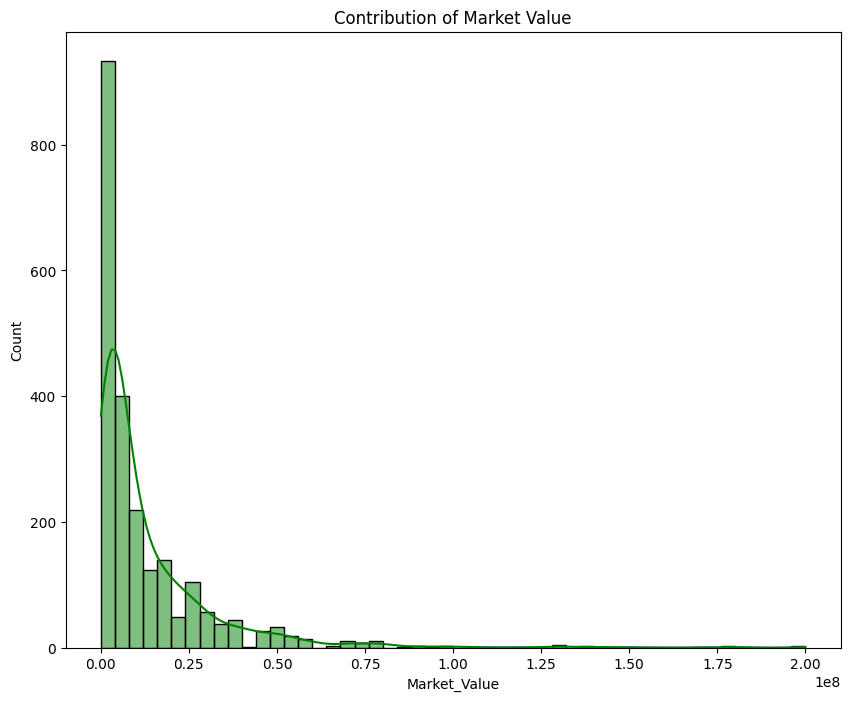

In [415]:
# Đối với 
plt.figure(figsize= (10, 8))
sns.histplot(data = data, x = 'Market_Value',  bins = 50, kde = True, color = 'green')
plt.title("Contribution of Market Value")

**Phân phối của Market Value bị skewness**

**=>** Đưa về phân phối chuẩn bằng Log ()

In [416]:
# Đổi đơn vị từ Euro thành triệu Euro
data['Market_Value'] = data['Market_Value'] / 1000000

In [417]:
data['Market_Value_log'] = np.log1p(data['Market_Value'])

Text(0.5, 1.0, 'Contribution of Market Value')

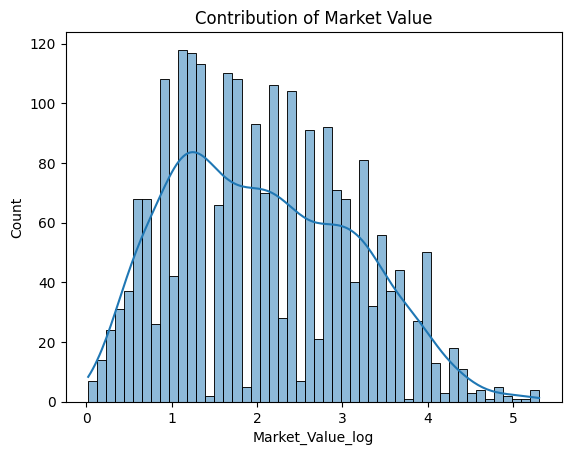

In [418]:
# Phân phối của Market Value sau khi chuẩn hóa 
sns.histplot(data = data, x = 'Market_Value_log',  bins = 50, kde = True, palette= 'green')
plt.title("Contribution of Market Value")

<Axes: xlabel='Market_Value_log'>

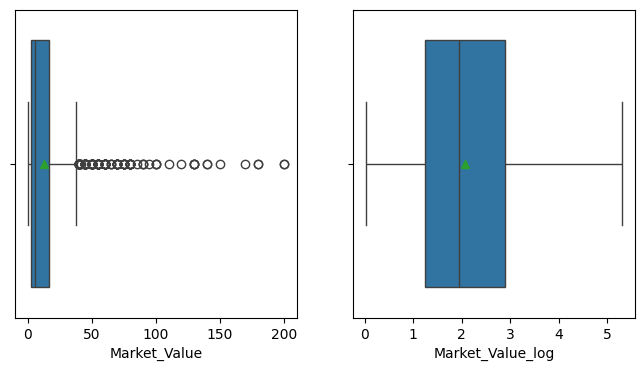

In [419]:
fig, ax = plt.subplots (1,2, figsize=(8,4))
sns.boxplot (x='Market_Value', data=data, showmeans=True, ax=ax[0])
sns.boxplot (x='Market_Value_log', data=data, showmeans=True, ax=ax[1])

- So sánh giá trị trung bình của cầu thủ dựa trên Quốc Tịch và Châu Lục
- So sánh giá trị cầu thủ dựa trên tuổi 
- So sánh giá trị cầu thủ dựa trên bàn thắng, kiến tạo 

- Phân phố đều tập trung quanh trong khoảng 23-26 tuổi 

## League and Market Value

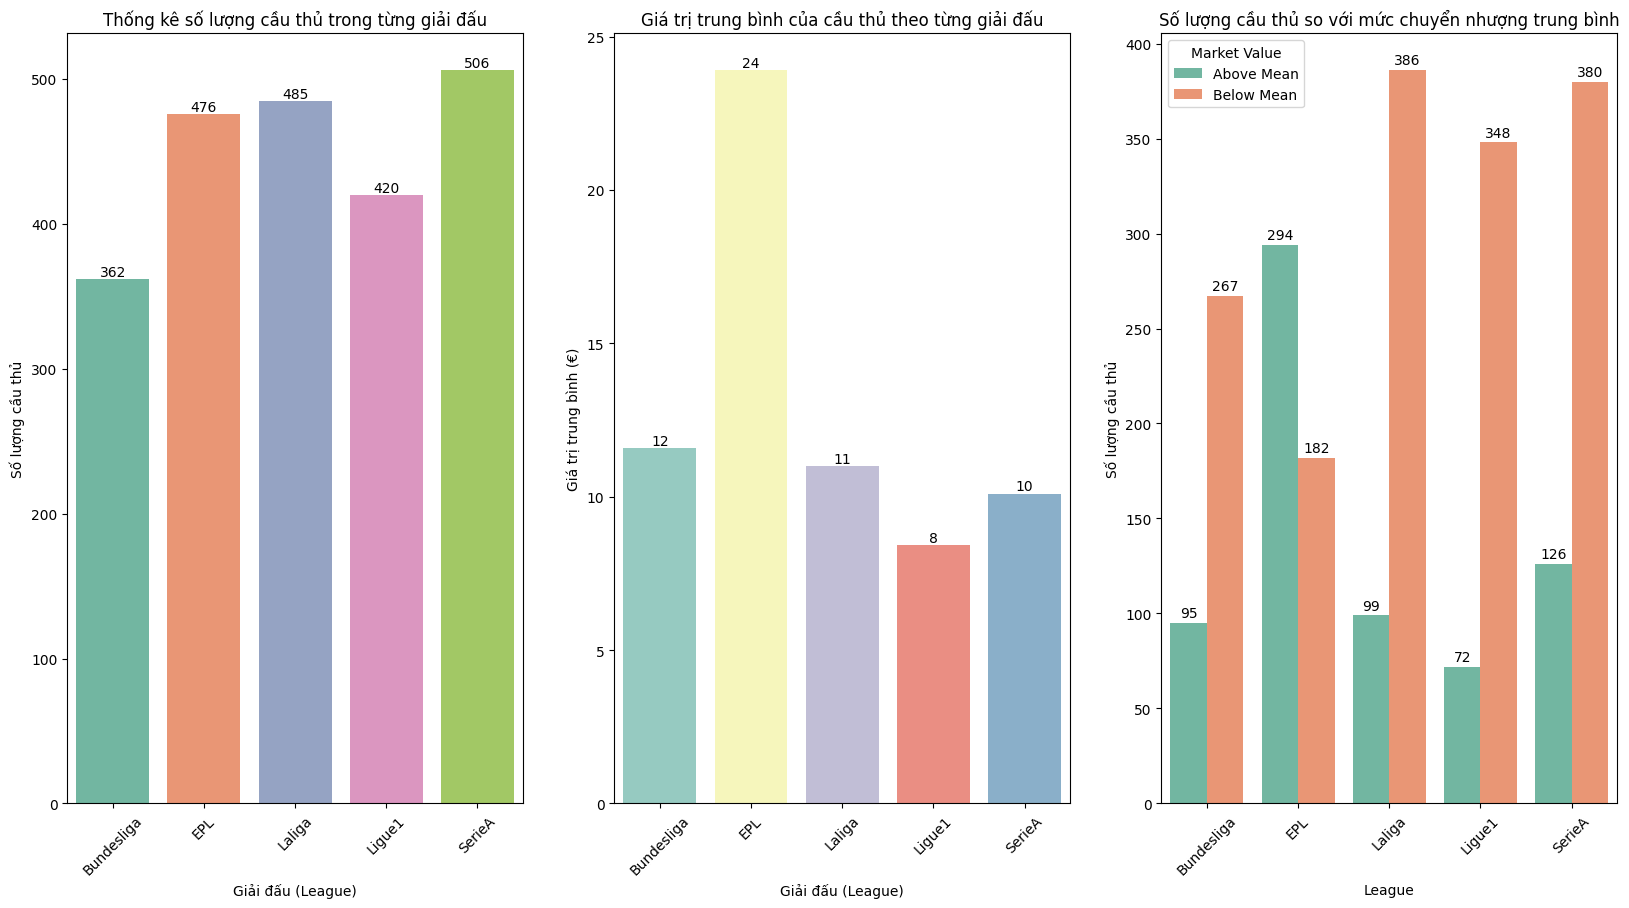

<Figure size 1000x600 with 0 Axes>

In [420]:
fig, ax = plt.subplots(1,3, figsize = (20, 10))
player_count = data.groupby('League')['Player'].count().reset_index()

player_count.columns = ['League', 'Player_Count']

plt.figure(figsize= (10, 6))
sns.barplot(ax = ax[0], data = player_count, x = 'League', y = 'Player_Count', palette = 'Set2')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')


ax[0].set_title("Thống kê số lượng cầu thủ trong từng giải đấu")
ax[0].set_xlabel('Giải đấu (League)')
ax[0].set_ylabel('Số lượng cầu thủ')
ax[0].tick_params(axis='x', rotation=45)

plt.tight_layout()


avg_value = data.groupby('League')['Market_Value'].mean().reset_index()
sns.barplot(ax=ax[1], data=avg_value, x='League', y='Market_Value', palette='Set3')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{height:,.0f}',  # có dấu phẩy phân cách hàng nghìn
                   (p.get_x() + p.get_width() / 2., height),
                   ha='center', va='bottom', fontsize=10, color='black')

ax[1].set_title("Giá trị trung bình của cầu thủ theo từng giải đấu")
ax[1].set_xlabel('Giải đấu (League)')
ax[1].set_ylabel('Giá trị trung bình (€)')
ax[1].tick_params(axis='x', rotation=45)

mean_value = data ['Market_Value'].mean ()
data ['Market_Category'] = data['Market_Value'].apply (lambda x: 'Above Mean' if x > mean_value else 'Below Mean')
sns.countplot (x='League', data=data, hue='Market_Category', palette='Set2', ax=ax[2])
for p in ax[2].patches:
    height = p.get_height ()
    if height > 0:
        ax[2].text (
            p.get_x () + p.get_width ()/2,
            height + 3,
            int (height),
            ha='center'
        )
ax[2].set_title ('Số lượng cầu thủ so với mức chuyển nhượng trung bình')
ax[2].set_xlabel ('League')
ax[2].set_ylabel ('Số lượng cầu thủ')
# plt.xticks (rotation=45)
ax[2].tick_params (axis='x', rotation=45)
# ax[0].grid ()
ax[2].legend (title='Market Value')

data.drop ('Market_Category', axis=1, inplace=True)

plt.tight_layout()
plt.show()

- Mặc dù số lượng các cầu thủ tại mỗi giải đấu là khá đồng đều
- Tuy nhiên EPL là giải đấu có giá trị cầu thủ chuyển nhượng cao vượt trội


## Foot and Market Value 

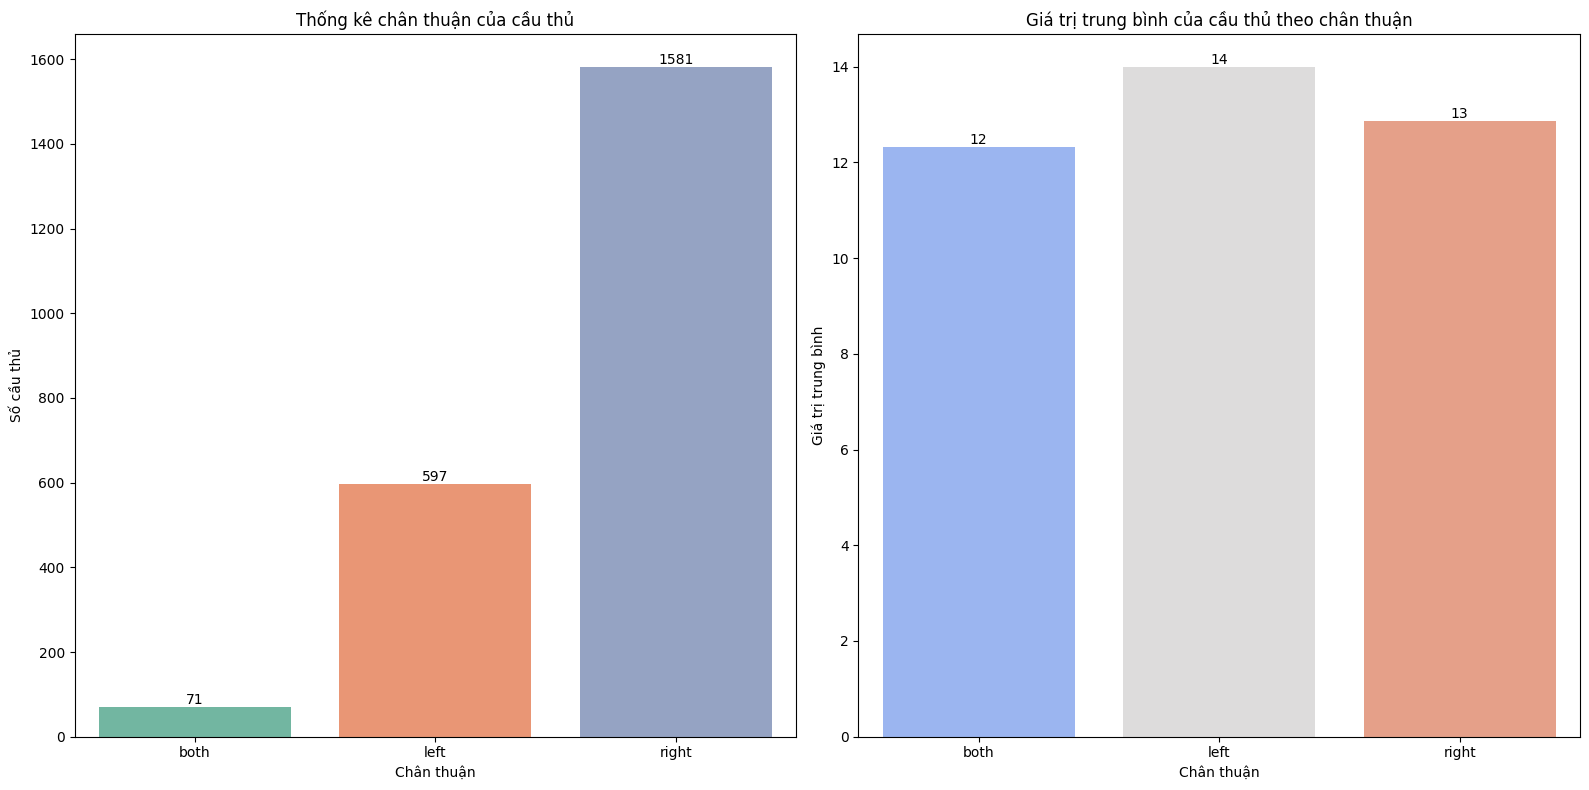

In [421]:
fig, ax = plt.subplots(1, 2, figsize = (16, 8))

# Thống kê chân thuận của cầu thủ 
foot_count = data.groupby('Foot')['Player'].count().reset_index()
sns.barplot(data = foot_count, x = 'Foot', y = 'Player', palette= 'Set2', ax = ax[0])
ax[0].set_title('Thống kê chân thuận của cầu thủ')
ax[0].set_title('Thống kê chân thuận của cầu thủ')
ax[0].set_xlabel('Chân thuận')
ax[0].set_ylabel('Số cầu thủ')

# Ghi giá trị lên cột
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2., height), 
                   ha='center', va='bottom', fontsize=10)
    

avg_value = data.groupby('Foot')['Market_Value'].mean().reset_index()
sns.barplot(data = avg_value, x = 'Foot', y = 'Market_Value', ax = ax[1], palette= 'coolwarm')
ax[1].set_title('Giá trị trung bình của cầu thủ theo chân thuận')
ax[1].set_xlabel('Chân thuận')
ax[1].set_ylabel('Giá trị trung bình')

# Ghi giá trị lên từng cột
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{height:,.0f}',  # format với dấu phẩy
                   (p.get_x() + p.get_width() / 2., height), 
                   ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

- Số lượng cầu thủ thuận cả 2 chân có rất ít, đa phân cầu thủ đều thuận chân phải 
- Giá trị của cầu thủ không ảnh hưởng quá nhiều đến chân thuận 

## Age and Market Value 

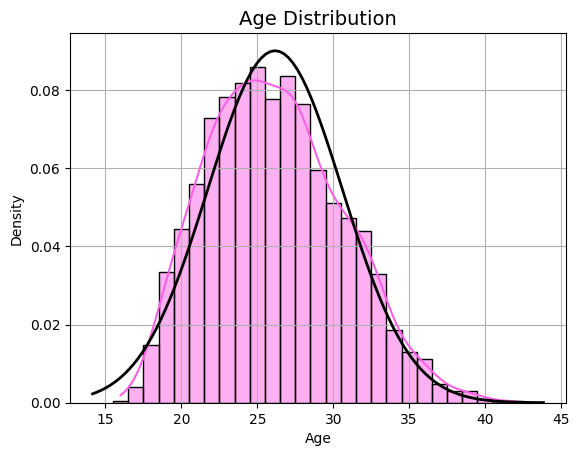

In [422]:
from scipy.stats import norm

sns.histplot(data = data, x = 'Age', kde = True, bins = 30, stat='density',color="#FB61E4", discrete=True)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, data['Age'].mean(), data['Age'].std())
plt.plot(x, p, 'k', linewidth=2)
plt.title ('Age Distribution', fontsize=14)
plt.grid ()

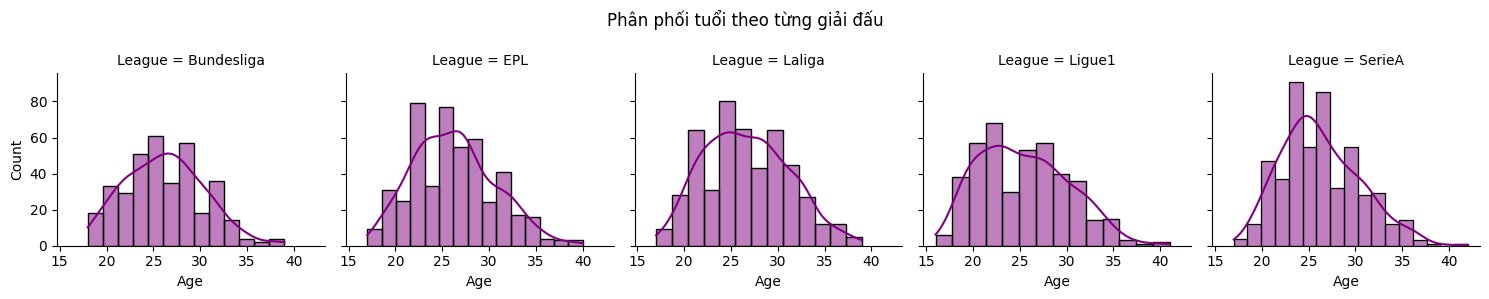

In [423]:
g = sns.FacetGrid(data, col='League')
g.map(sns.histplot, 'Age', kde=True, color='purple')

plt.suptitle ('Phân phối tuổi theo từng giải đấu')
plt.tight_layout ()
plt.show()

Text(0.5, 1.0, 'Age - League')

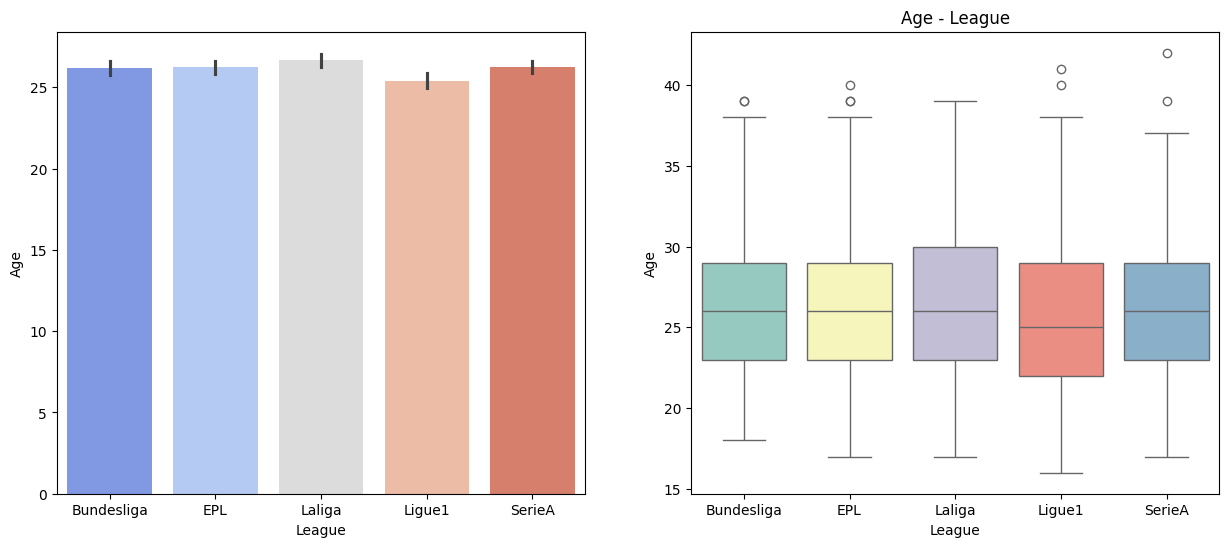

In [424]:
fig, ax = plt.subplots (1, 2, figsize=(15, 6))
sns.barplot (
    x='League', 
    y='Age', 
    data=data, 
    estimator='mean', 
    palette='coolwarm',
    ax=ax[0]
)

sns.boxplot (
    x='League',y='Age', data=data, ax=ax[1], palette='Set3'
)
ax[1].set_title ('Age - League')

`Nhận xét`
- Độ tuổi trung bình của cầu thủ ở cả 5 giải đấu khá đồng đều
- Có 1 số cầu thủ có độ tuổi khá lớn (outliers)

<Axes: xlabel='Age', ylabel='Market_Value_log'>

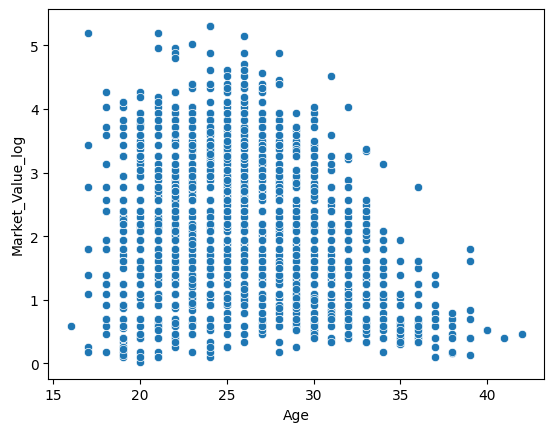

In [425]:
sns.scatterplot(data = data, x = 'Age', y = 'Market_Value_log')

Text(0.5, 1.0, 'Giá trị của cầu thủ dựa vào tuổi và giải đấu')

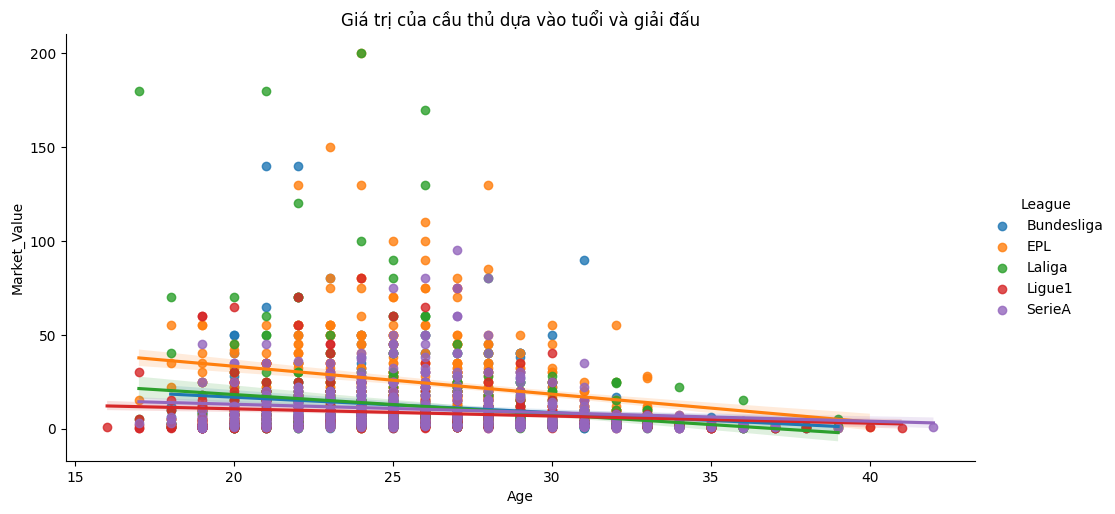

In [426]:
sns.lmplot (data=data, x='Age', y='Market_Value', hue='League',aspect=2)
plt.title('Giá trị của cầu thủ dựa vào tuổi và giải đấu')

Text(0.5, 1.0, 'Phân phối tuổi của các cầu thủ')

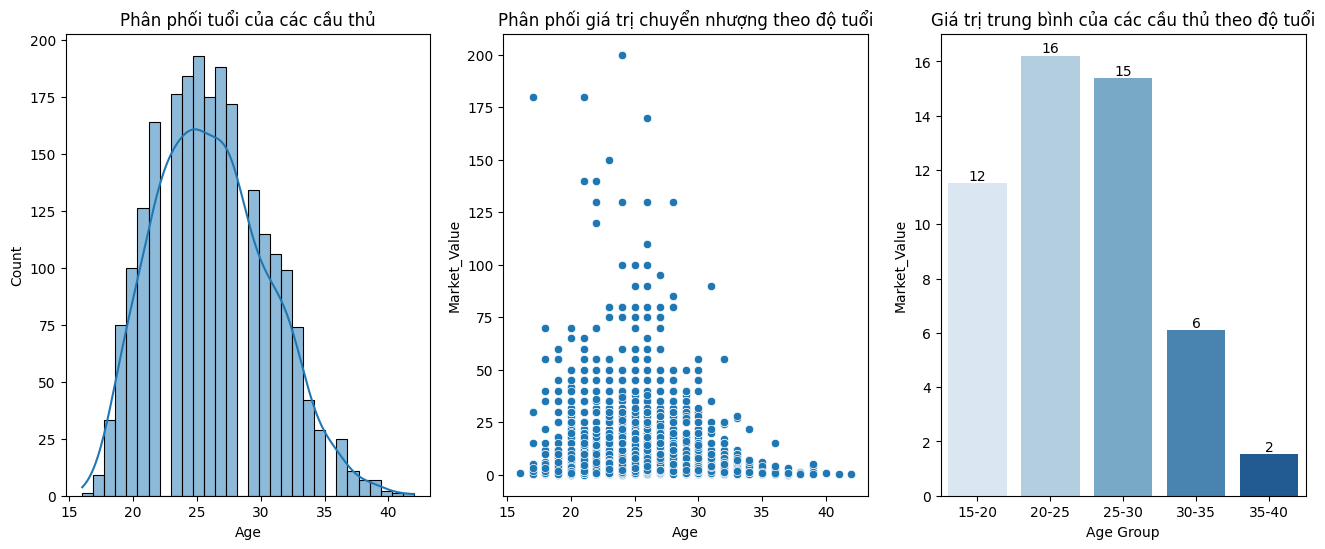

In [427]:
fig, ax = plt.subplots(1, 3, figsize = (16, 6))

bins = [15, 20, 25, 30, 35, 40]
labels = ['15-20', '20-25', '25-30', '30-35', '35-40']
df = data.copy()
df['Age_Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

avg_value_by_age_group = df.groupby('Age_Group')['Market_Value'].mean().reset_index()
avg_value_by_age_group.columns = ['Age_Group', 'Avg_Market_Value']


sns.barplot(data=avg_value_by_age_group, x='Age_Group', y='Avg_Market_Value', palette='Blues', ax = ax[2])
for p in ax[2].patches:
    height = p.get_height()
    ax[2].annotate(f'{height:,.0f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)
ax[2].set_title('Giá trị trung bình của các cầu thủ theo độ tuổi')
ax[2].set_xlabel('Age Group')
ax[2].set_ylabel('Market_Value')


sns.scatterplot(data = data, x = 'Age', y = 'Market_Value', ax = ax[1])
ax[1].set_title('Phân phối giá trị chuyển nhượng theo độ tuổi')

sns.histplot(data = data, x = 'Age', kde = True, bins = 30, ax = ax[0])
ax[0].set_title("Phân phối tuổi của các cầu thủ")

- Phân phối tuổi gần chuẩn và tập trung xoanh quanh điểm trung bình 25
- Nhóm cầu thủ có giá trị cao nhất là từ 20-25 và 25 - 30
- Nhóm 30-35 và 35-40 có giá trị thấp 
- Có một số cầu thủ từ khoảng 20-30 có giá trị rất cao > 100 million Euro 

## Red and Yellow card

In [428]:
data ['Age'] = data['Age'].astype (int)
data ['Height'] = data ['Height'].astype (int)
data ['Yel'] = data ['Yel'].astype (int)
data ['Red'] = data ['Red'].astype (int)
data ['Goals'] = data ['Goals'].astype (int)
data ['Assists'] = data ['Assists'].astype (int)
data ['MotM'] = data ['MotM'].astype (int)

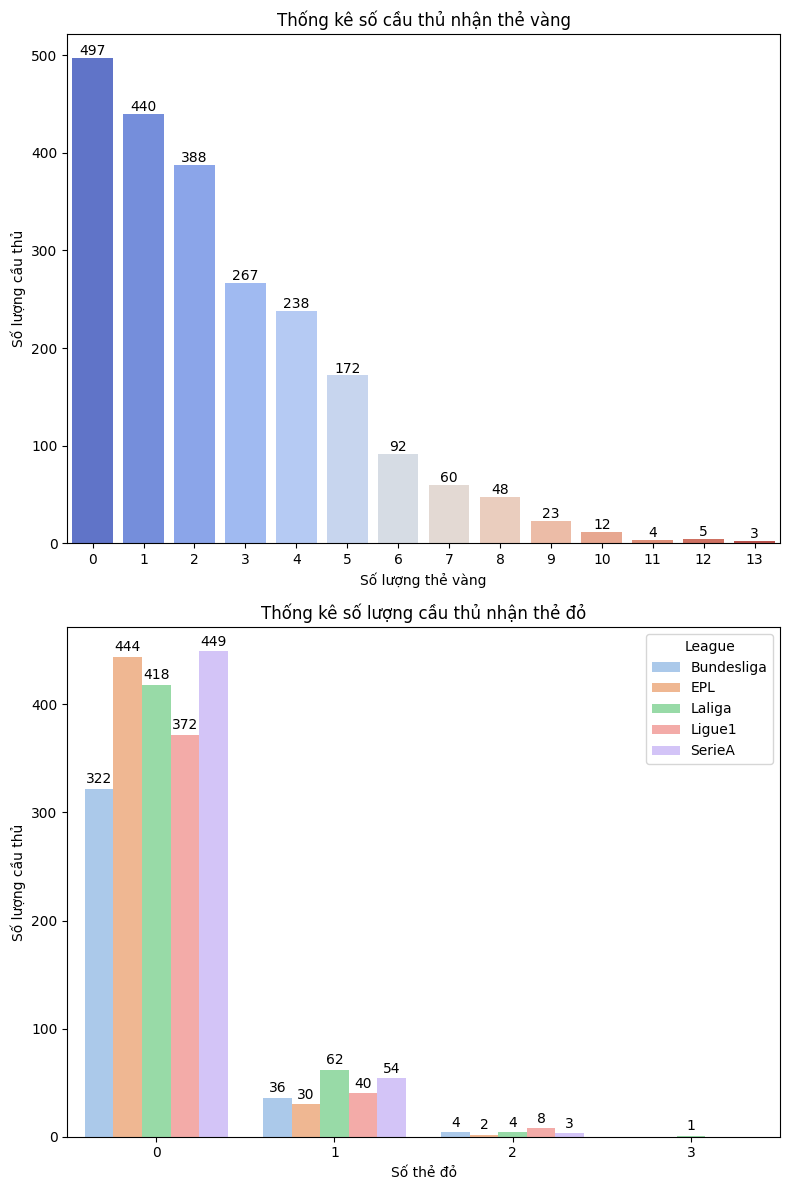

In [429]:
fig, ax=plt.subplots (2, 1, figsize=(8,12))
sns.countplot (x='Yel', data=data, palette='coolwarm',ax=ax[0])
for p in ax[0].patches:
    height = p.get_height ()
    if height > 0:
        ax[0].text (
            p.get_x () + p.get_width ()/2,
            height + 3,
            int (height),
            ha='center'
        )
ax[0].set_title ('Thống kê số cầu thủ nhận thẻ vàng')
ax[0].set_xlabel ('Số lượng thẻ vàng')
ax[0].set_ylabel ('Số lượng cầu thủ')
        
sns.countplot (x='Red', data=data, palette='pastel', hue='League', ax=ax[1])
ax[1].set_title ('Thống kê số lượng cầu thủ nhận thẻ đỏ')
ax[1].set_xlabel ('Số thẻ đỏ')
ax[1].set_ylabel ('Số lượng cầu thủ')
for p in ax[1].patches:
    height = p.get_height ()
    if height > 0:
        ax[1].text (
            p.get_x () + p.get_width ()/2,
            height + 5,
            int (height),
            ha='center'
        )
        
plt.tight_layout ()
plt.show ()

# Feature Extract (2)

## Yel, Red
Yel, Red --> Card

In [430]:
data['Card'] = data['Yel'] + data['Red'] * 2
# Một thẻ đỏ bằng 2 thẻ vàng 
data['Card'] = data['Card'].astype(int)

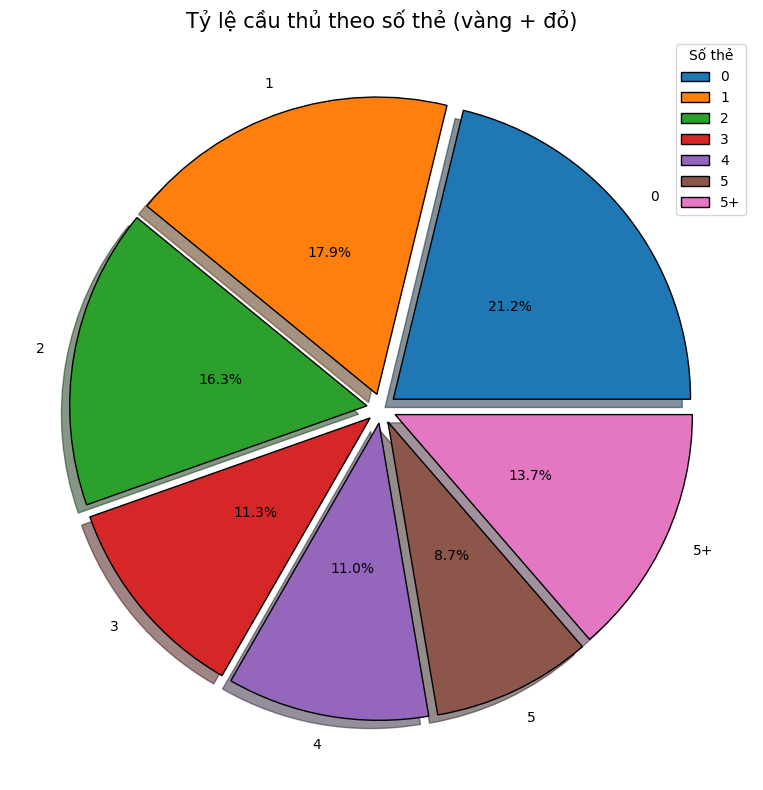

In [431]:
# Đếm số thẻ
card_counts_full = data['Card'].value_counts().sort_index()

# Lấy thẻ <= 5
card_counts = card_counts_full[card_counts_full.index <= 5].copy()

# Gộp nhóm thẻ > 5
card_counts['5+'] = card_counts_full[card_counts_full.index > 5].sum()

# Labels tương ứng với card_counts mới
labels = card_counts.index.astype(str)

explode = [0.05] * len(labels)
wp = {'linewidth': 1, 'edgecolor': 'black'}

plt.figure(figsize=(8, 8))
plt.pie(x=card_counts.values,
        labels=labels,
        autopct="%.1f%%",
        pctdistance=0.5,
        explode=explode,
        shadow=True,
        wedgeprops=wp)

plt.title("Tỷ lệ cầu thủ theo số thẻ (vàng + đỏ)", fontsize=15)
plt.legend(title="Số thẻ")
plt.tight_layout()
plt.show()


- Nhóm những cầu thủ có > 5+ thẻ (2 * đỏ + vàng) vào một nhóm

## Main_Position
Main_Position --> Position_Group

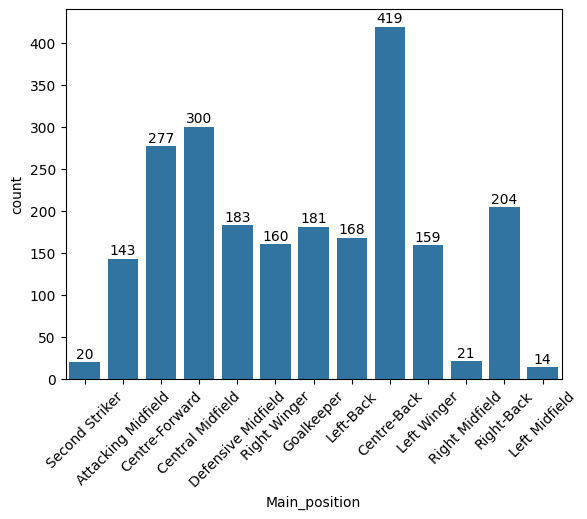

In [432]:
ax = sns.countplot(data = data, x = 'Main_position')
for p in ax.patches:
    height = p.get_height ()
    if height > 0:
        ax.text (
            p.get_x () + p.get_width ()/2,
            height + 5,
            int (height),
            ha='center'
        )
plt.tick_params(axis='x', rotation=45)

In [433]:
# Nhóm thủ môn + hậu vệ (phòng ngự)
group_defense = ['Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back']

# Nhóm tiền vệ 
group_midfield = ['Defensive Midfield', 'Central Midfield', 'Left Midfield', 'Right Midfield']

# Nhóm tiền đạo 
group_attack = ['Centre-Forward', 'Second Striker', 'Attacking Midfield', 'Left Winger', 'Right Winger']

def map_position(pos):
    if pos in group_defense:
        return 'Phòng ngự'
    elif pos in group_midfield:
        return 'Tiền vệ'
    elif pos in group_attack:
        return 'Tiền đạo'
    else:
        return 'Khác'
data['Position_Group'] = data['Main_position'].apply(map_position)

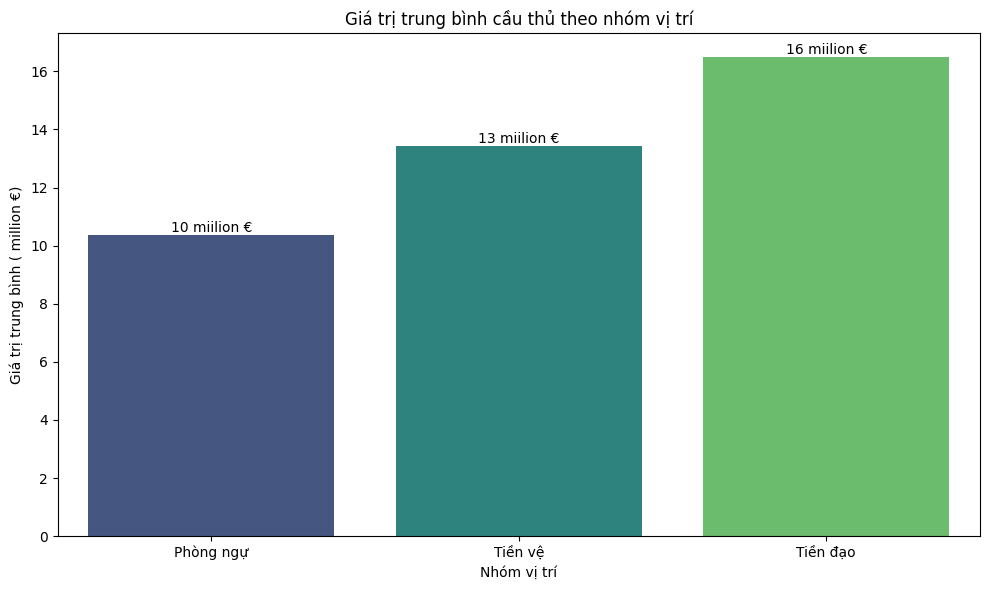

In [434]:
avg_value_by_group = data.groupby('Position_Group')['Market_Value'].mean().reset_index()
avg_value_by_group.columns = ['Position_Group', 'Avg_Market_Value']
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
ax = sns.barplot(data=avg_value_by_group, x='Position_Group', y='Avg_Market_Value', palette='viridis')

# Ghi giá trị lên cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,.0f} miilion €', (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10)

plt.title("Giá trị trung bình cầu thủ theo nhóm vị trí")
plt.xlabel("Nhóm vị trí")
plt.ylabel("Giá trị trung bình ( million €)")
plt.tight_layout()
plt.show()


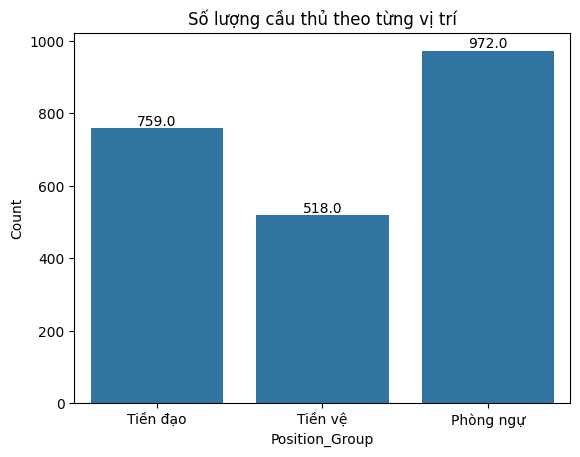

In [435]:
data['Position_Group'].value_counts()
ax = sns.countplot(data = data, x= 'Position_Group')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',  # giá trị đếm
                xy=(p.get_x() + p.get_width() / 2, height),  # vị trí ghi
                ha='center', va='bottom', fontsize=10)
plt.title('Số lượng cầu thủ theo từng vị trí')
plt.ylabel('Count')
plt.show()

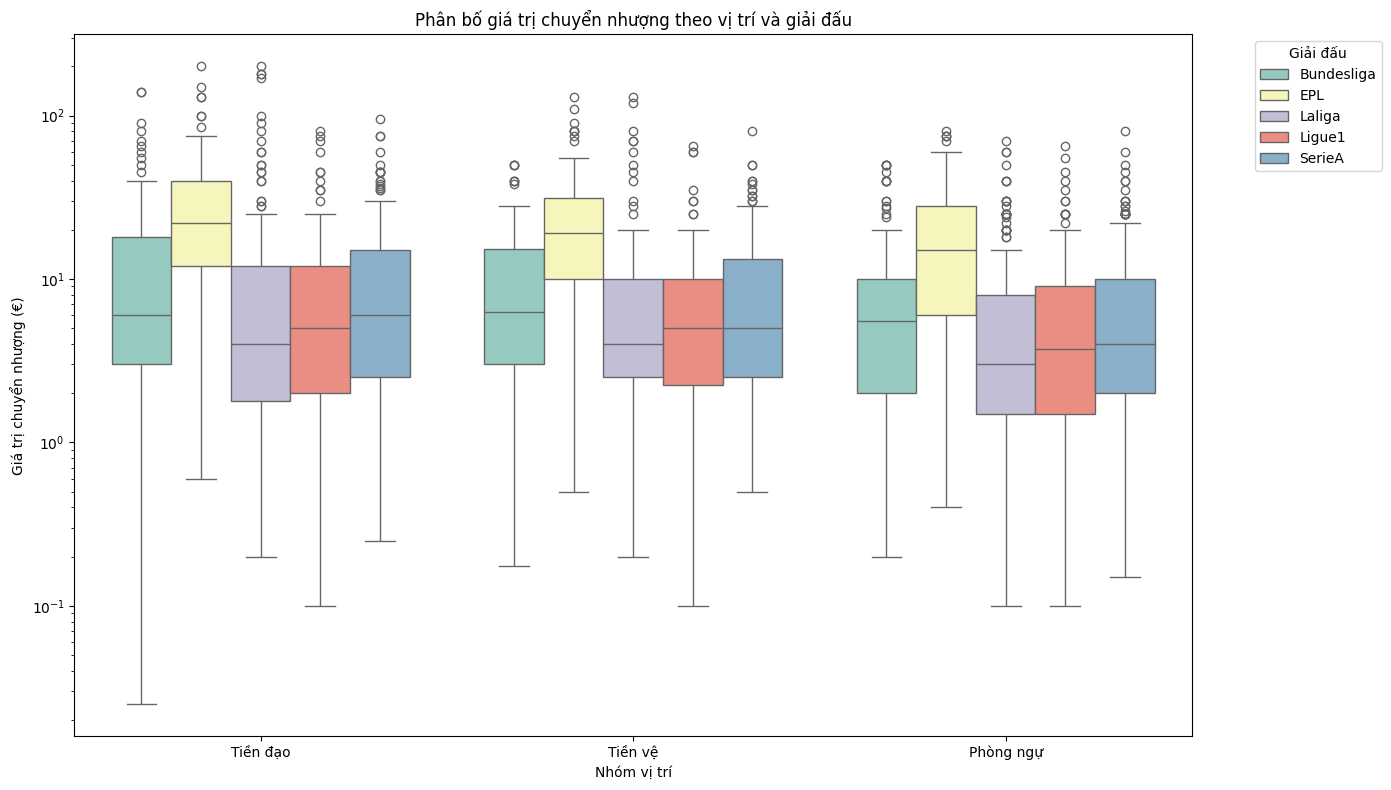

In [436]:
plt.figure(figsize=(14,8))
sns.boxplot(data=data, x='Position_Group', y='Market_Value', hue='League', palette='Set3')
plt.title('Phân bố giá trị chuyển nhượng theo vị trí và giải đấu')
plt.ylabel('Giá trị chuyển nhượng (€)')
plt.xlabel('Nhóm vị trí')
plt.yscale('log')  # Nếu giá trị phân bố rất rộng, dùng log scale giúp dễ nhìn
plt.legend(title='Giải đấu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<Axes: xlabel='Position_Group', ylabel='Market_Value'>

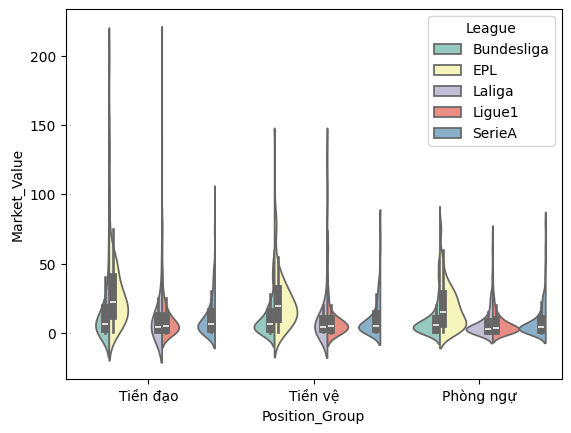

In [437]:
sns.violinplot(data=data, x='Position_Group', y='Market_Value', hue='League', palette='Set3', split=True)

- EPL vẫn là giải đấu có giá trị cầu thủ cao nhất tại mọi vị trí trên sân


## National 
National --> Continent

In [438]:
data['National'].unique()

array(['Czech Republic', 'Germany', 'France', 'Spain', 'Sweden',
       'Austria', 'Canada', 'Mali', 'Belgium', 'Morocco', 'Norway',
       'Denmark', 'Serbia', 'Croatia', 'Portugal', 'Eritrea',
       'Burkina Faso', 'Switzerland', 'Slovenia', 'Brazil', 'Georgia',
       'Turkey', 'England', 'Costa Rica', 'Netherlands', 'Israel',
       'Slovakia', 'Tunisia', 'Argentina', 'Bosnia-Herzegovina', 'Italy',
       'Algeria', 'Kosovo', 'Nigeria', 'Finland', 'USA', 'Japan',
       'South Korea', 'Ukraine', 'Poland', 'Estonia', 'Greece', 'Guinea',
       'Scotland', 'Ecuador', 'Hungary', 'Sierra Leone', 'Benin',
       'Uzbekistan', 'Ivory Coast', 'Cameroon', 'Ghana', 'Albania',
       'Wales', 'Jamaica', 'Australia', 'Ireland', 'New Zealand',
       'N. Ireland', 'Colombia', 'Uruguay', 'Mexico', 'Senegal',
       'Paraguay', 'Zimbabwe', 'Egypt', 'Zambia', 'Romania', 'Gambia',
       'DR Congo', 'Iceland', 'Russia', 'Macedonia', 'Venezuela',
       'Equatorial Guinea', 'Dominican Rep.', 'Peru

In [439]:
continent_map = {
    'Europe': ['Germany', 'Georgia', 'Austria', 'Serbia', 'Netherlands', 'Croatia', 'Norway',
               'France', 'Switzerland', 'Spain', 'Finland', 'Czech Republic', 'England',
               'Portugal', 'Sweden', 'Turkey', 'Italy', 'Belgium', 'Denmark', 'Greece',
               'Poland', 'Estonia', 'Slovenia', 'Slovakia', 'Hungary', 'Kosovo',
               'Scotland', 'Bosnia-Herzegovina', 'Ukraine', 'Wales', 'Iceland', 'Ireland',
               'Albania', 'Romania', 'Macedonia', 'Russia', 'Malta', 'Cyprus', 'Armenia',
               'Montenegro', 'Lithuania', 'N. Ireland'],

    'American': ['Brazil', 'Argentina', 'Ecuador', 'Colombia', 'Paraguay', 'Uruguay',
                'Peru', 'Venezuela', 'Chile','USA', 'Canada', 'Costa Rica', 'Mexico', 'Jamaica',
                'Dominican Rep.','Haiti', 'Guadeloupe', 'Panama'],

    'Africa': ['Sierra Leone', 'Morocco', 'Burkina Faso', 'Nigeria', 'Algeria', 'Guinea',
               'Tunisia', 'Benin', 'Eritrea', 'Mali', 'Ghana', 'Cameroon', 'Ivory Coast',
               'DR Congo', 'Gambia', 'Senegal', 'Egypt', 'Zambia', 'Zimbabwe',
               'Equatorial Guinea', 'Libya', 'Gabon', 'Burundi', 'Angola',
               'Central African Rep.', 'Guinea-Bissau', 'Kenya', 'Congo'],

    'Asia': ['South Korea', 'Japan', 'Israel', 'Uzbekistan', 'Saudi Arabia', 'Iran',
             'U.A.E.'],

    'Oceania': ['Australia', 'New Zealand']
}

def map_continent (country):
    for continent, country_list in continent_map.items ():
        if country in country_list:
            return continent
    return 'Unknown'

data ['Continent'] = data['National'].apply (map_continent)

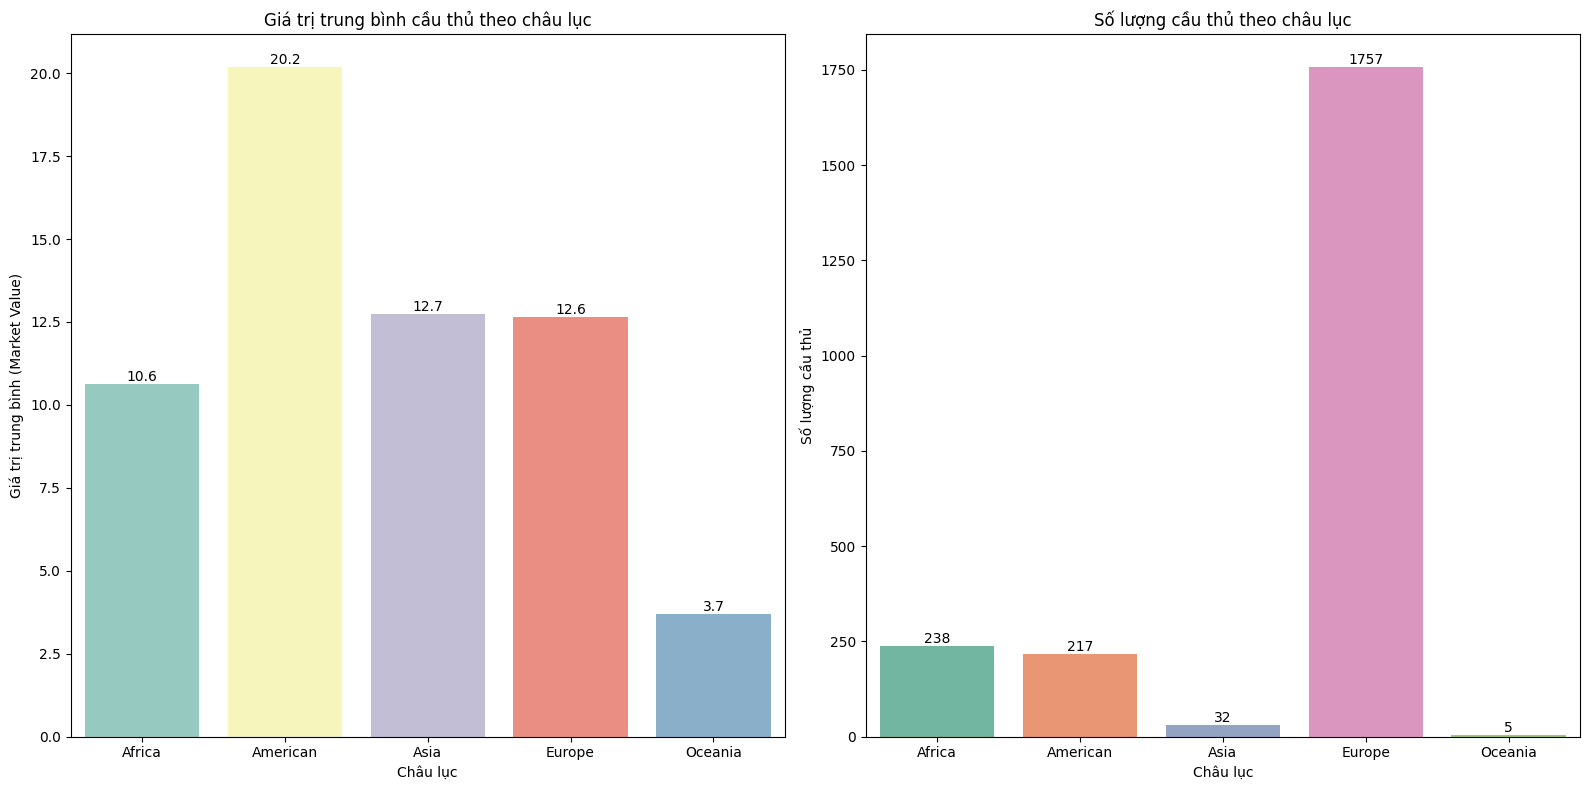

In [440]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Biểu đồ 1: Giá trị trung bình cầu thủ theo châu lục
avg_value_by_continent = data.groupby('Continent')['Market_Value'].mean().reset_index()
sns.barplot(ax=ax[0], data=avg_value_by_continent, x='Continent', y='Market_Value', palette='Set3')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{height:.1f}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[0].set_title("Giá trị trung bình cầu thủ theo châu lục")
ax[0].set_xlabel("Châu lục")
ax[0].set_ylabel("Giá trị trung bình (Market Value)")

# Biểu đồ 2: Số lượng cầu thủ theo châu lục
player_count_by_continent = data.groupby('Continent')['Player'].count().reset_index()
player_count_by_continent.columns = ['Continent', 'Player_Count']
sns.barplot(ax=ax[1], data=player_count_by_continent, x='Continent', y='Player_Count', palette='Set2')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[1].set_title("Số lượng cầu thủ theo châu lục")
ax[1].set_xlabel("Châu lục")
ax[1].set_ylabel("Số lượng cầu thủ")

plt.tight_layout()
plt.show()


- Số lượng cầu thủ Châu Âu cao nhất -> Đơn giản vì dữ liệu lấy từ 5 giải VĐQG Châu Âu
- Châu Mỹ mới là châu lục có giá trị cầu thủ cao nhất, thấp nhất là châu ÚC
- Châu Phi, Á, Âu có giá trị cầu thủ trung bình gần ngang nhau (chênh lệch không đáng kể)
=> Có thể xem xét việc gộp Châu Úc, Châu Á và Châu Mỹ lại 1 thành Châu Úc Mỹ Á :v 


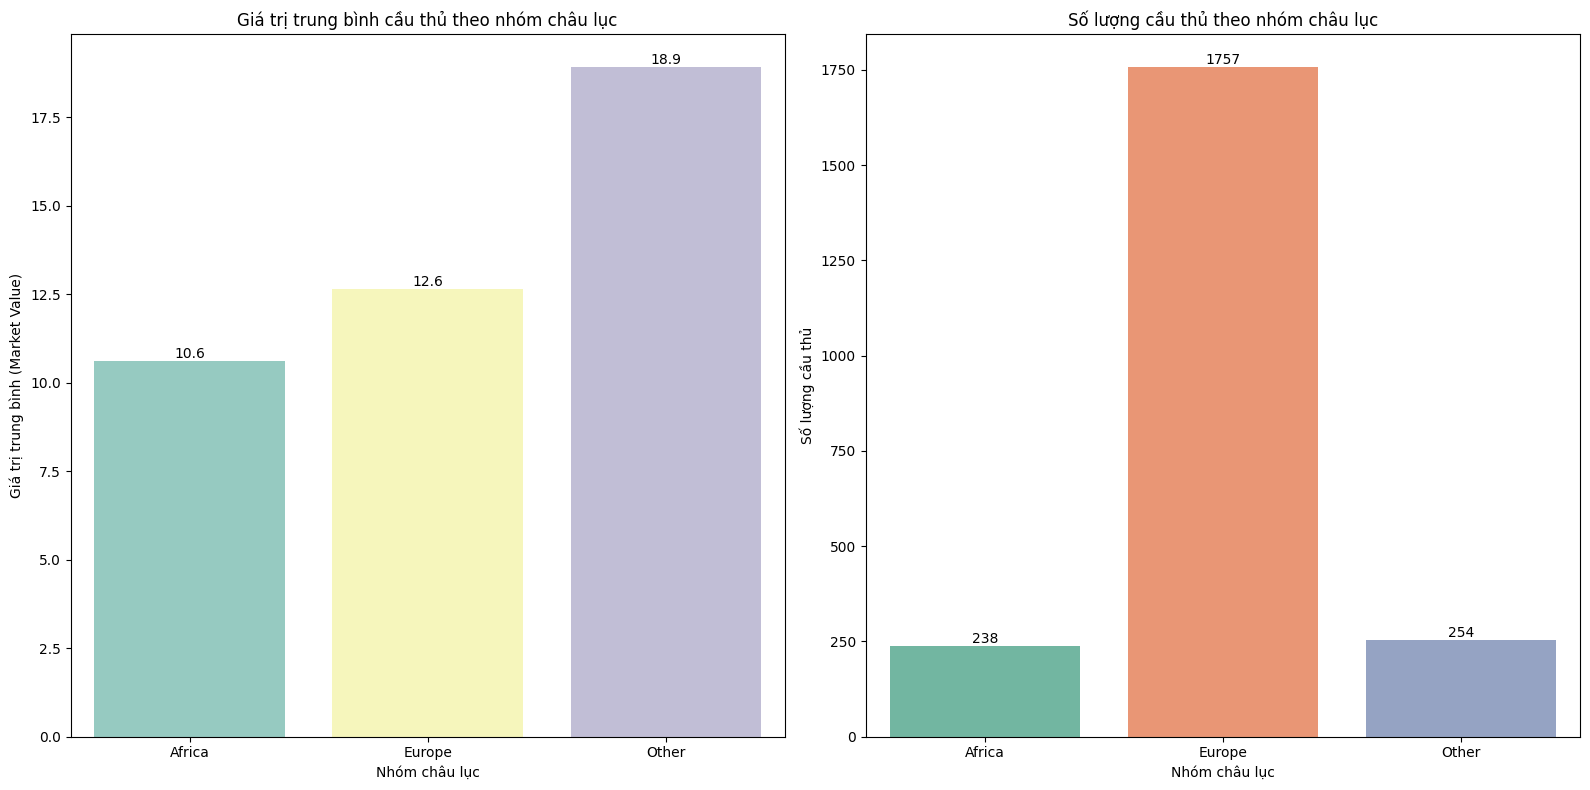

In [441]:
def merge_continents(continent):
    '''Ghép khu vực Oceania, Asia, Americas thành 1'''
    if continent in ['Oceania', 'Asia', 'American']:
        return 'Other'
    else:
        return continent

data['Continent_Grouped'] = data['Continent'].apply(merge_continents)

# Tính trung bình giá trị theo nhóm mới
avg_value_by_continent_grouped = data.groupby('Continent_Grouped')['Market_Value'].mean().reset_index()

# Tính số lượng cầu thủ theo nhóm mới
player_count_by_continent_grouped = data.groupby('Continent_Grouped')['Player'].count().reset_index()
player_count_by_continent_grouped.columns = ['Continent_Grouped', 'Player_Count']

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(ax=ax[0], data=avg_value_by_continent_grouped, x='Continent_Grouped', y='Market_Value', palette='Set3')
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(f'{height:.1f}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[0].set_title("Giá trị trung bình cầu thủ theo nhóm châu lục")
ax[0].set_xlabel("Nhóm châu lục")
ax[0].set_ylabel("Giá trị trung bình (Market Value)")

sns.barplot(ax=ax[1], data=player_count_by_continent_grouped, x='Continent_Grouped', y='Player_Count', palette='Set2')
for p in ax[1].patches:
    height = p.get_height()
    ax[1].annotate(f'{int(height)}', 
                   (p.get_x() + p.get_width() / 2, height),
                   ha='center', va='bottom',
                   fontsize=10, color='black')
ax[1].set_title("Số lượng cầu thủ theo nhóm châu lục")
ax[1].set_xlabel("Nhóm châu lục")
ax[1].set_ylabel("Số lượng cầu thủ")

plt.tight_layout()
plt.show()


Gộp Úc, Mỹ, Á Thành một gọi là Other 

In [442]:
categorical_col

['Player', 'Club', 'League', 'National', 'Main_position', 'Foot']

## Club 
Club --> Club_Group

In [443]:
avg_value_by_club = data.groupby('Club')['Market_Value'].mean().reset_index()
avg_value_by_club = avg_value_by_club.sort_values('Market_Value', ascending=False)

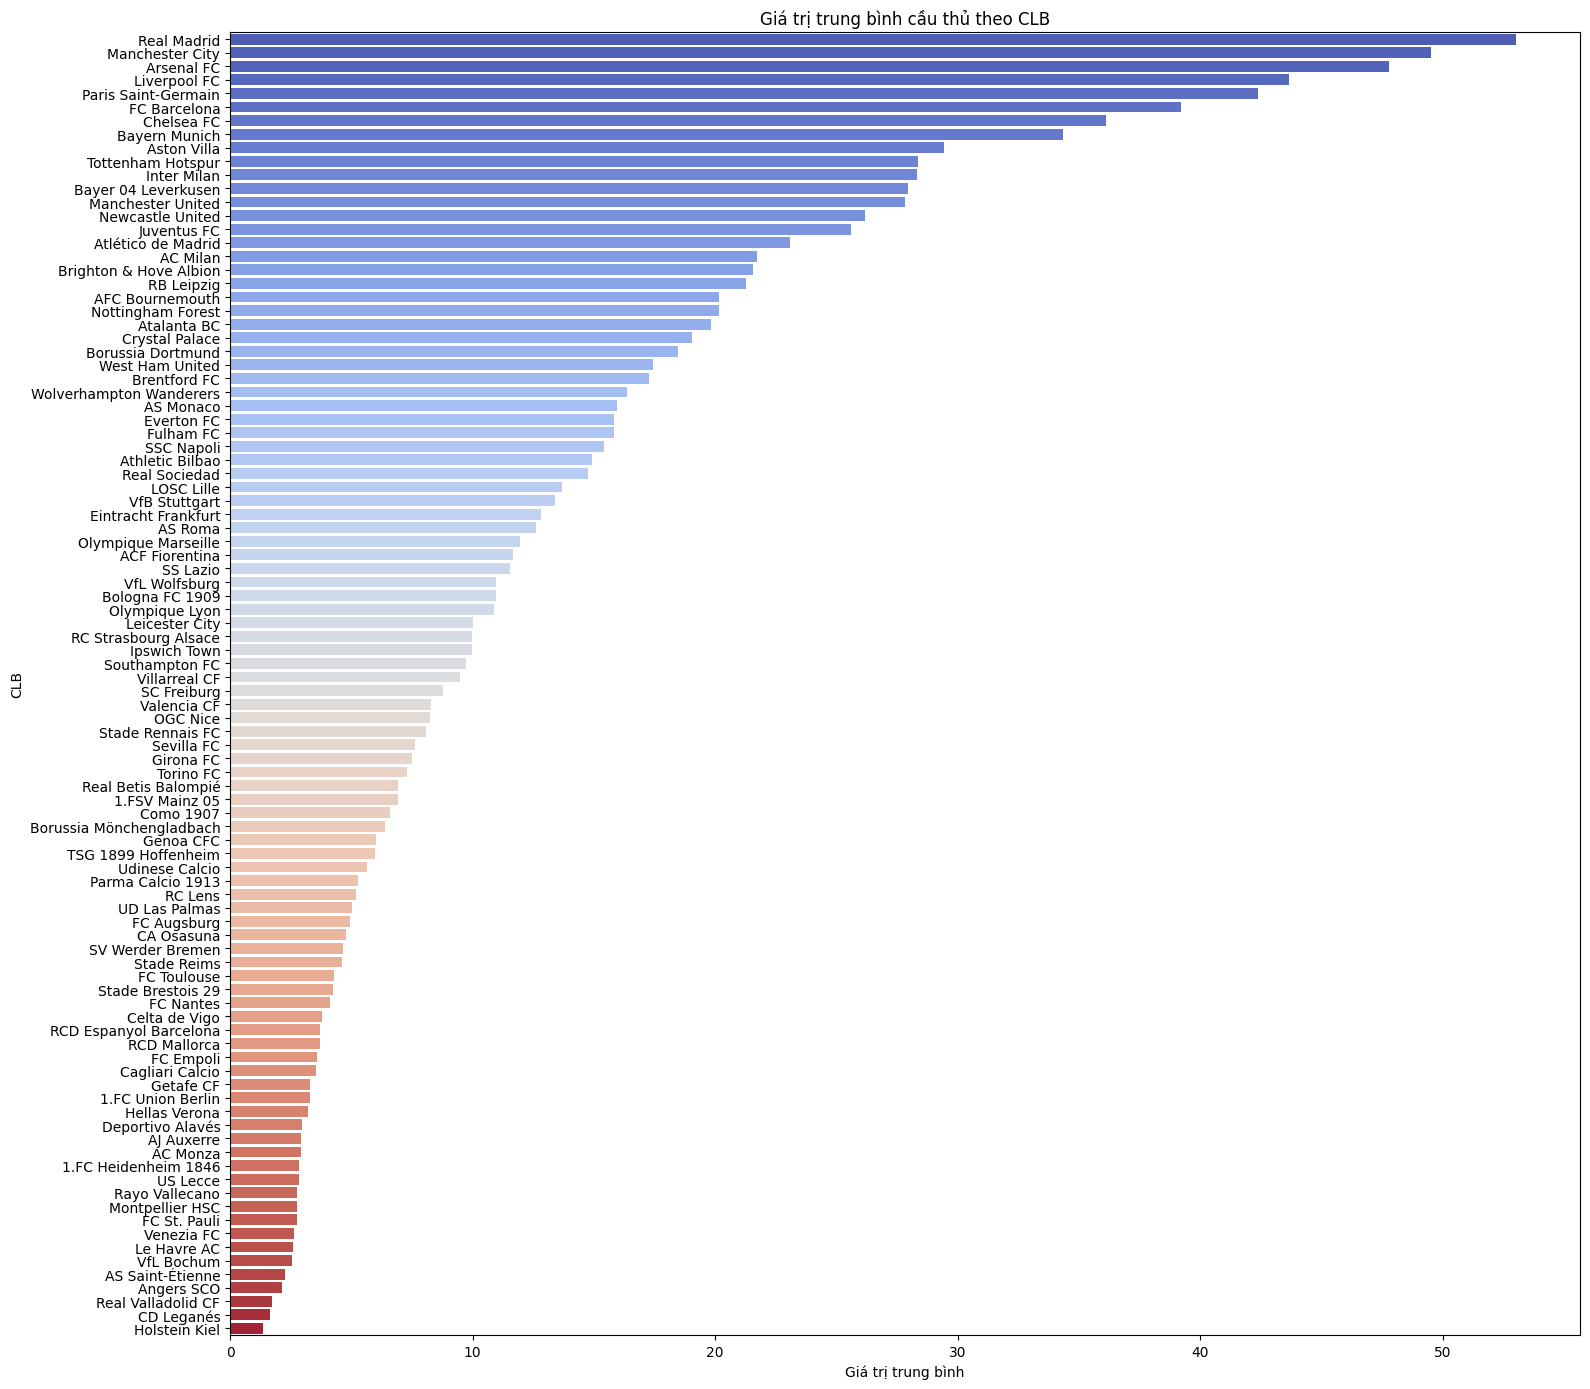

In [444]:
plt.figure(figsize=(16, 14))
sns.barplot(data=avg_value_by_club, x='Market_Value', y='Club', palette='coolwarm')
plt.title('Giá trị trung bình cầu thủ theo CLB')
plt.xlabel('Giá trị trung bình')
plt.ylabel('CLB')
plt.tight_layout()
plt.show()


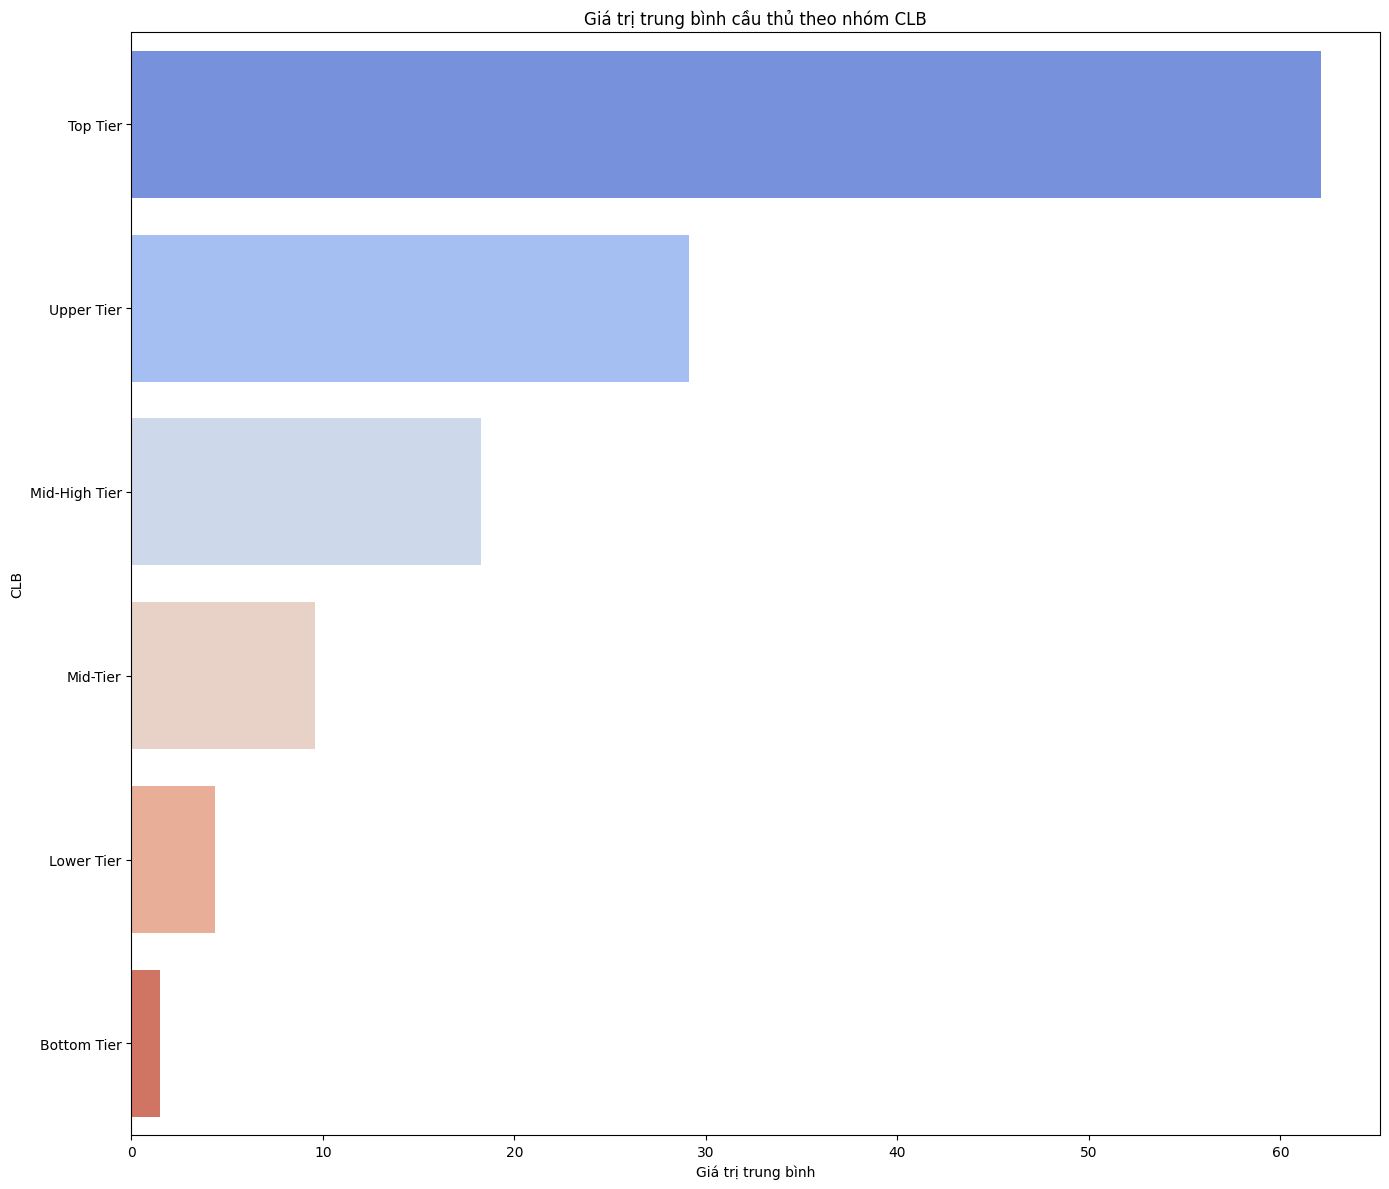

In [445]:
# Nhóm CLB thành các group như sau : 
def classify_market_value(value):
    if value >= 40:
        return 'Top Tier' # Tầm cao nhất
    elif value >= 25:
        return 'Upper Tier' # Tầm cao
    elif value >= 15:
        return 'Mid-High Tier' # Trung bình khá
    elif value >= 7:
        return 'Mid-Tier' # Trung bình
    elif value >= 3:
        return 'Lower Tier' # Thấp
    else:
        return 'Bottom Tier' # Rất thấp
    
data['Club_Group'] = data['Market_Value'].apply(classify_market_value)

avg_value_by_club = data.groupby('Club_Group')['Market_Value'].mean().reset_index()
avg_value_by_club = avg_value_by_club.sort_values('Market_Value', ascending=False)
plt.figure(figsize=(14, 12))

sns.barplot(data=avg_value_by_club, x='Market_Value', y='Club_Group', palette='coolwarm')
plt.title('Giá trị trung bình cầu thủ theo nhóm CLB')
plt.xlabel('Giá trị trung bình')
plt.ylabel('CLB')
plt.tight_layout()
plt.show()

## Goals and MotM and Rating 

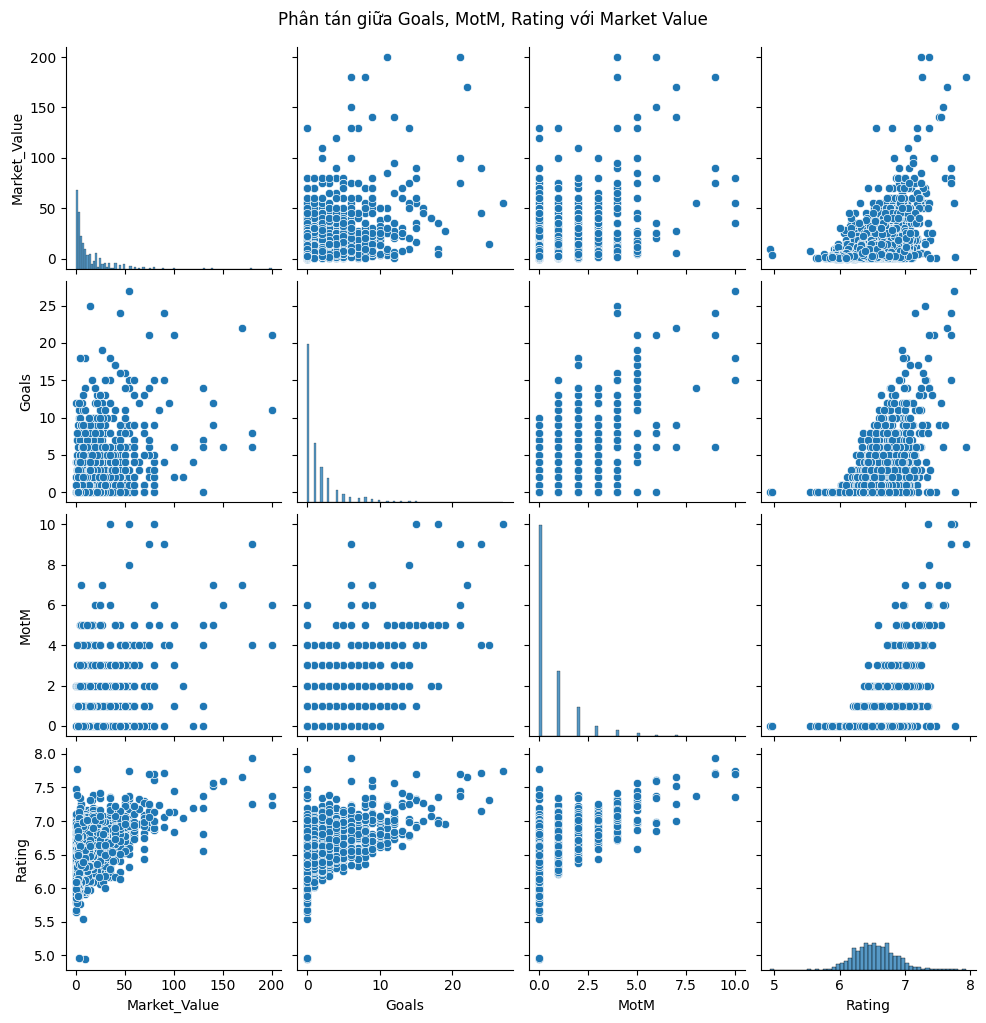

In [446]:
sns.pairplot(data[['Market_Value', 'Goals', 'MotM', 'Rating']])
plt.suptitle("Phân tán giữa Goals, MotM, Rating với Market Value", y=1.02)
plt.show()

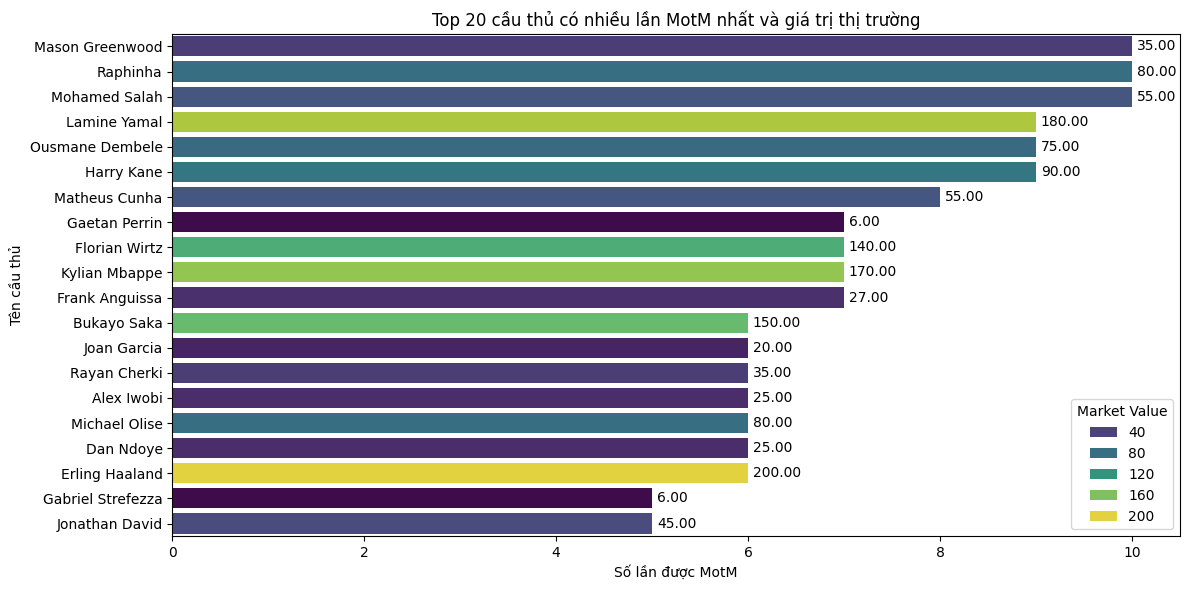

In [447]:
# Sắp xếp giảm dần theo số lần được MotM
top_20_motm = data.sort_values(by='MotM', ascending=False).head(20)

# Lấy ra các cột cần thiết
top_20_motm_info = top_20_motm[['Player', 'MotM', 'Market_Value', 'Age']]

plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=top_20_motm_info, x='MotM', y='Player', hue='Market_Value', dodge=False, palette='viridis')
plt.title('Top 20 cầu thủ có nhiều lần MotM nhất và giá trị thị trường')
plt.xlabel('Số lần được MotM')
plt.ylabel('Tên cầu thủ')
plt.legend(title='Market Value')
plt.tight_layout()
for i, (motm, player, mv) in enumerate(zip(top_20_motm_info['MotM'], top_20_motm_info['Player'], top_20_motm_info['Market_Value'])):
    barplot.text(
        motm + 0.05,   # đặt vị trí text hơi lệch phải so với thanh
        i,            # đúng thứ tự y
        f'{mv:.2f}',  # format giá trị market value
        color='black',
        va='center'
    )

plt.tight_layout()
plt.show()
plt.show()


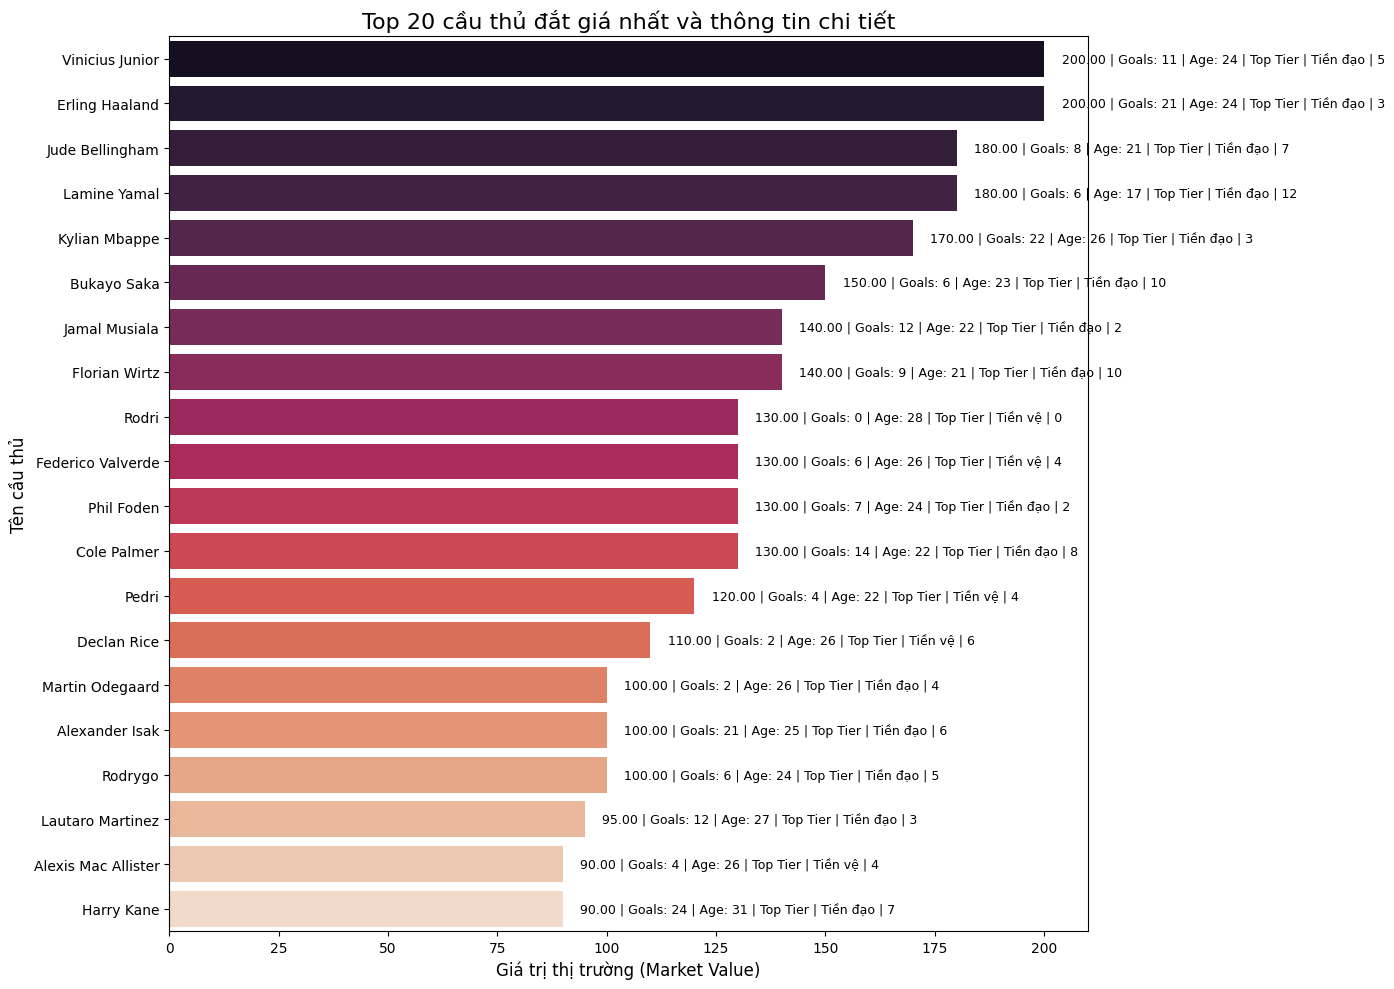

In [360]:
top_player = data[['Player', 'Market_Value', 'Goals', 'Age', 'League', 'Club', 'Club_Group', 'Position_Group', 'Assists']].sort_values(
    by='Market_Value', ascending=False).head(20)

plt.figure(figsize=(14, 10))
sns.barplot(
    data=top_player,
    x='Market_Value',
    y='Player',
    palette='rocket'
)

plt.title('Top 20 cầu thủ đắt giá nhất và thông tin chi tiết', fontsize=16)
plt.xlabel('Giá trị thị trường (Market Value)', fontsize=12)
plt.ylabel('Tên cầu thủ', fontsize=12)

# Hiển thị nhãn gồm Market Value, Goals, Age, League, Club
for i, (value, goals, age, league, group_club, position, club, assist) in enumerate(zip(
        top_player['Market_Value'],
        top_player['Goals'],
        top_player['Age'],
        top_player['League'],
        top_player['Club_Group'],
        top_player['Position_Group'],
        top_player['Club'],
        top_player['Assists'])):

    label = f'{value:.2f} | Goals: {goals} | Age: {age} | {group_club} | {position} | {assist}'
    plt.text(value + 0.02 * top_player['Market_Value'].max(), i, label,
             va='center', fontsize=9)

plt.tight_layout()
plt.show()


- Các vị trí Tiện Đạo và Tiền Vệ là những vị trí có giá trị cao 
- Nếu Tiền Đaọ có giá trị cao thì số bàn thắng phải nhiều
- Nếu Tiền Vệ có giá trị cao thì số kiến tạo phải nhiều
- 20 người có giá trị cao nhất đều nằm trong nhóm các CLB (Top Tier)

In [448]:
data.columns

Index(['Player', 'Club', 'League', 'Age', 'National', 'Height',
       'Main_position', 'Foot', 'Market_Value', 'Months_left', 'Start_app',
       'Sub_app', 'Mins', 'Goals', 'Assists', 'Yel', 'Red', 'SpG', 'PS%',
       'AerialsWon', 'MotM', 'Rating', 'TotAD', 'WonAD', 'LostAD', 'CrAss',
       'CorAss', 'ThrbAss', 'FreAss', 'ThrInAss', 'OthAss', 'TotAss', 'BlkSh',
       'BlkCr', 'BlkPs', 'YelC', 'RedC', 'TotClr', 'UnDrib', 'SucDrib',
       'TotDrib', 'Fouled', 'Fouls', 'TotGs', 'SYBGs', 'PAGs', 'OOBGs',
       'TotInt', 'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs', 'AccLB', 'InAccLB',
       'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav', 'SYBSav', 'PASav',
       'OOBSav', 'TotSh', 'OOBSh', 'SYBSh', 'PASh', 'TotTkl', 'DribPast',
       'TotAttTkl', 'Market_Value_log', 'Card', 'Position_Group', 'Continent',
       'Continent_Grouped', 'Club_Group'],
      dtype='object')

In [ ]:
# Thuộc tính ThInAss chỉ có 1 giá trị => Không mang lại lợi ích cho mô hình 
data['ThrInAss'].unique()

array([0.])

In [450]:
data = data.drop(columns= ['Player', 'ThrInAss'])
data.to_csv ('Silver_Data_LGBM.csv')
data_encoded = data.copy()
drop_col = ['Club', 'National', 'Main_position', 'Yel', 'Red', 'Continent', 'Market_Value_log', 'YelC', 'RedC']
data_encoded = data_encoded.drop(columns= drop_col)

In [451]:
one_hot_encoded_col = ['League', 'Foot', 'Position_Group', 'Continent_Grouped', 'Club_Group']

data_encoded = pd.get_dummies(data_encoded, columns=one_hot_encoded_col, prefix=one_hot_encoded_col, drop_first= True)


In [365]:
data_encoded.columns

Index(['Age', 'Height', 'Market_Value', 'Months_left', 'Start_app', 'Sub_app',
       'Mins', 'Goals', 'Assists', 'SpG', 'PS%', 'AerialsWon', 'MotM',
       'Rating', 'TotAD', 'WonAD', 'LostAD', 'CrAss', 'CorAss', 'ThrbAss',
       'FreAss', 'OthAss', 'TotAss', 'BlkSh', 'BlkCr', 'BlkPs', 'TotClr',
       'UnDrib', 'SucDrib', 'TotDrib', 'Fouled', 'Fouls', 'TotGs', 'SYBGs',
       'PAGs', 'OOBGs', 'TotInt', 'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs',
       'AccLB', 'InAccLB', 'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav',
       'SYBSav', 'PASav', 'OOBSav', 'TotSh', 'OOBSh', 'SYBSh', 'PASh',
       'TotTkl', 'DribPast', 'TotAttTkl', 'Card', 'League_EPL',
       'League_Laliga', 'League_Ligue1', 'League_SerieA', 'Foot_left',
       'Foot_right', 'Position_Group_Tiền vệ', 'Position_Group_Tiền đạo',
       'Continent_Grouped_Europe', 'Continent_Grouped_Other',
       'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier',
       'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper T

# Correlation Matrix

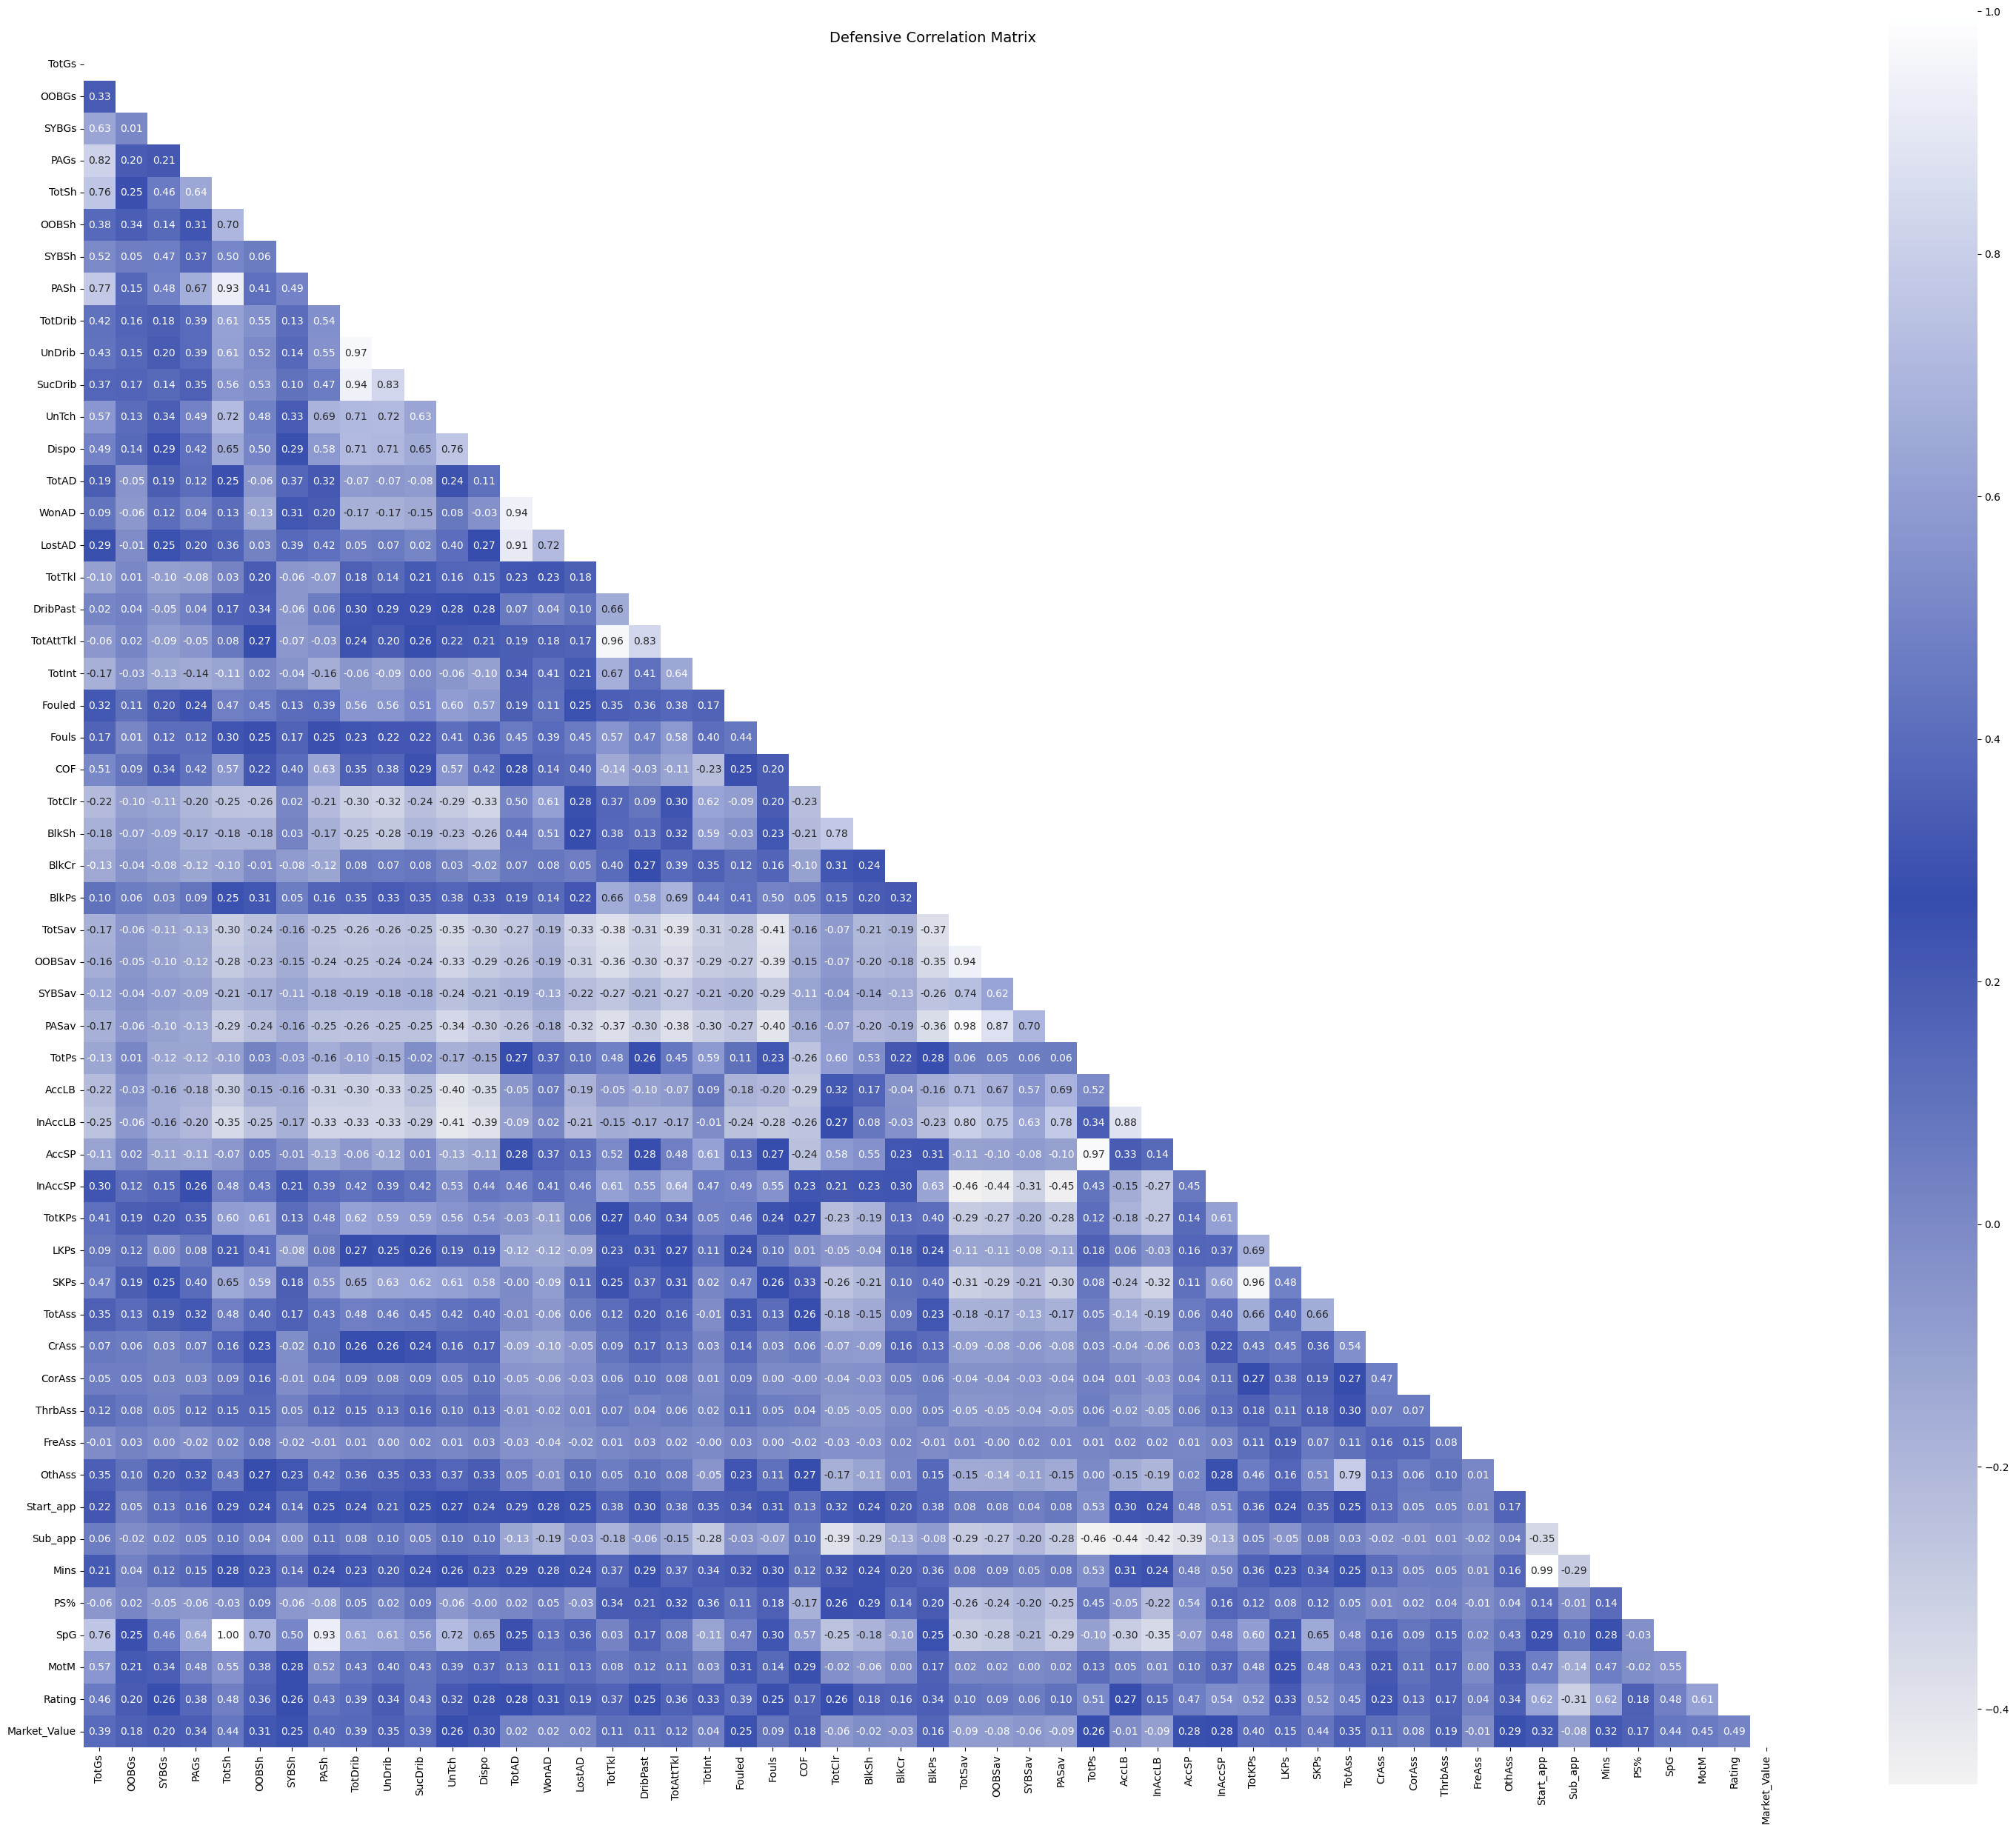

In [366]:
from matplotlib.colors import LinearSegmentedColormap

full_cols = [
    'TotGs', 'OOBGs', 'SYBGs', 'PAGs',  # Goal - Features
    'TotSh', 'OOBSh', 'SYBSh', 'PASh',  # Shoot - Features
    'TotDrib', 'UnDrib', 'SucDrib',     # Dribble - Features
    'UnTch', 'Dispo',                   # Touch - Features
    'TotAD', 'WonAD', 'LostAD',         # Aerial - Features
    'TotTkl', 'DribPast', 'TotAttTkl', 'TotInt',  
    'Fouled', 'Fouls', 'COF', 'TotClr',  
    'BlkSh', 'BlkCr', 'BlkPs',    
    'TotSav', 'OOBSav',                   
    'SYBSav', 'PASav',         
    'TotPs', 'AccLB', 'InAccLB', 'AccSP', 'InAccSP',                        # Passes Features
    'TotKPs', 'LKPs', 'SKPs',                                               # Key Pass Features
    'TotAss', 'CrAss', 'CorAss', 'ThrbAss', 'FreAss', 'OthAss', # Assists Features
    "Start_app",  # Số trận đá chính
    "Sub_app",    # Số trận vào sân thay người
    "Mins",       # Số phút thi đấu (mọi vị trí),
    "PS%",        # Tỷ lệ chuyền chính xác (%)
    "SpG",        # Sút mỗi trận (tiền vệ hoặc tiền đạo)
    "MotM",       # Man of the Match (cầu thủ xuất sắc nhất trận)
    "Rating",     # Đánh giá chung hiệu suất cầu thủ,
    'Market_Value'
]
Full_df = data [full_cols]
corr = Full_df.corr ()

plt.figure (figsize=(30, 25))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#364cad", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Defensive Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

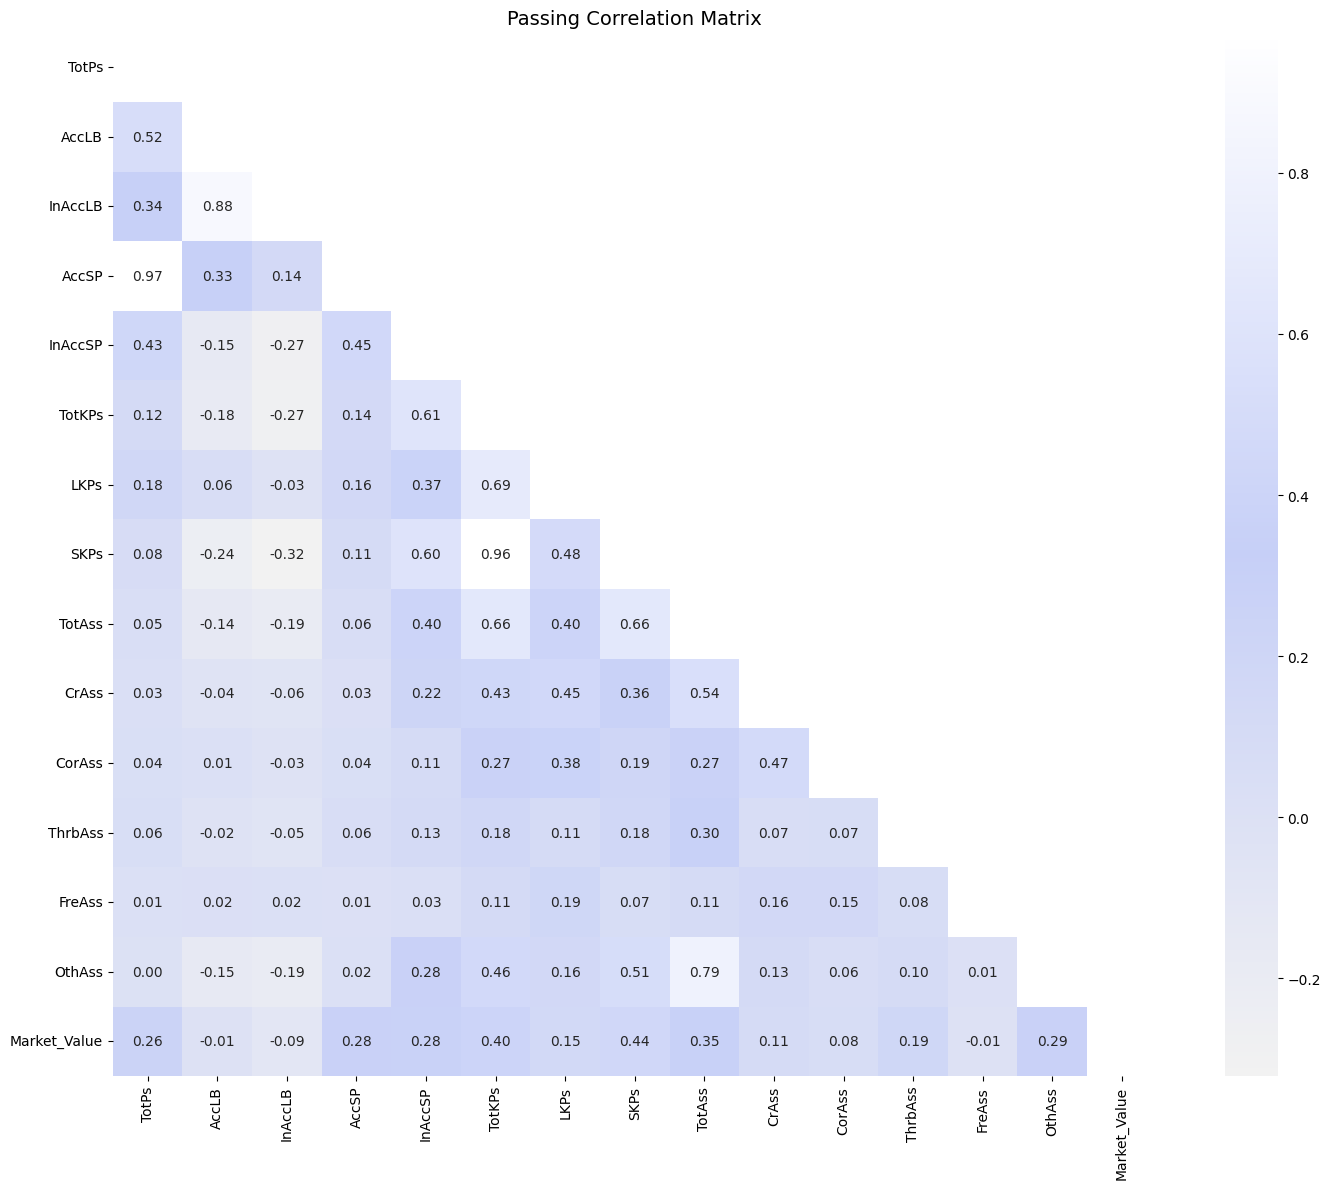

In [452]:
from matplotlib.colors import LinearSegmentedColormap

passing_cols = [
    'TotPs', 'AccLB', 'InAccLB', 'AccSP',
    'InAccSP', 'TotKPs', 'LKPs', 'SKPs',
    'TotAss', 'CrAss', 'CorAss', 'ThrbAss',
    'FreAss', 'OthAss',
    "Market_Value"
]

Passing_df = data_encoded[passing_cols]
corr = Passing_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#c6cff7", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Passing Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Đối với một cầu thủ ở vị trí Tiền Vệ .Giá trị thị trường của các tiền vệ có tương quan mạnh với : 
    + Điểm trung bình được các nhà báo thể thao đánh giá sau mỗi trận : Rating (0.49)
    + Số lần được bầu là cầu thủ xuất săc nhất trận : MotM (0.45)
    + Số cú sút trung bình mỗi trận : SpG(0.44)
    + Số đường truyền ngắn : SKPs(0.44)
    + Tổng số đường truyền quyết đinh : TotKPs (0.40)


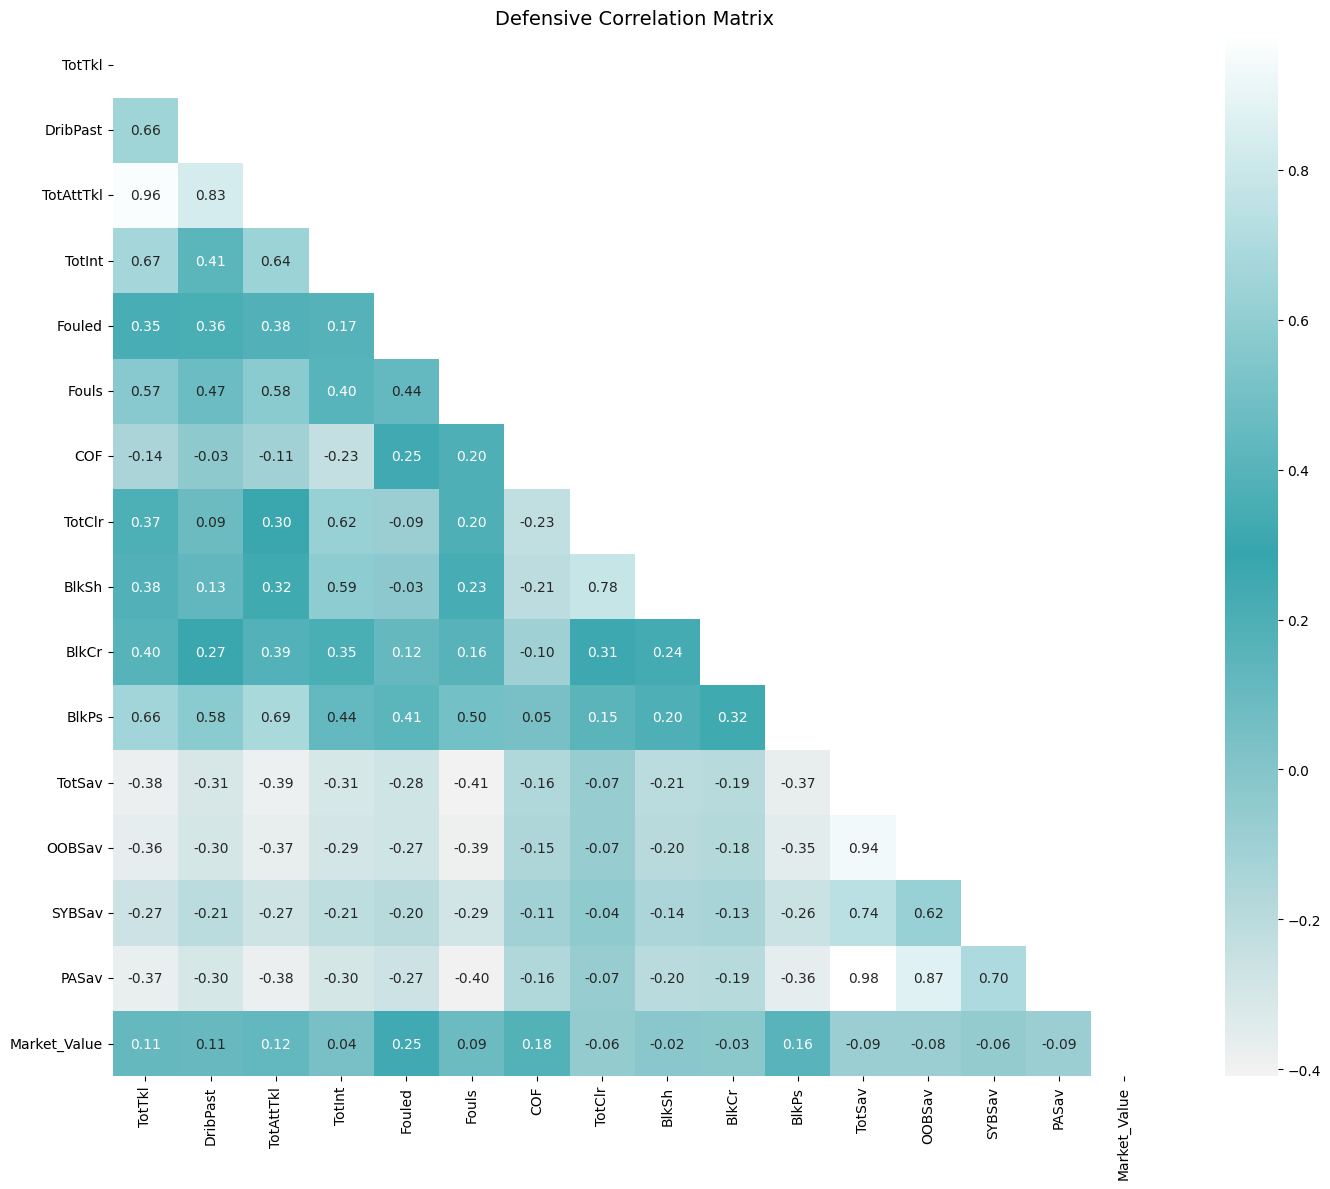

In [368]:
from matplotlib.colors import LinearSegmentedColormap

defensive_cols = [
    'TotTkl', 'DribPast', 'TotAttTkl', 'TotInt',  
    'Fouled', 'Fouls', 'COF', 'TotClr',  
    'BlkSh', 'BlkCr', 'BlkPs',    
    'TotSav', 'OOBSav',                   
    'SYBSav', 'PASav',         
    'Market_Value'
]

Defensive_df = data_encoded[defensive_cols]
corr = Defensive_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#36a5ad", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Defensive Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Giá trị các cầu thủ Phòng ngự có tương quan mạnh đến Fouled (0.25)

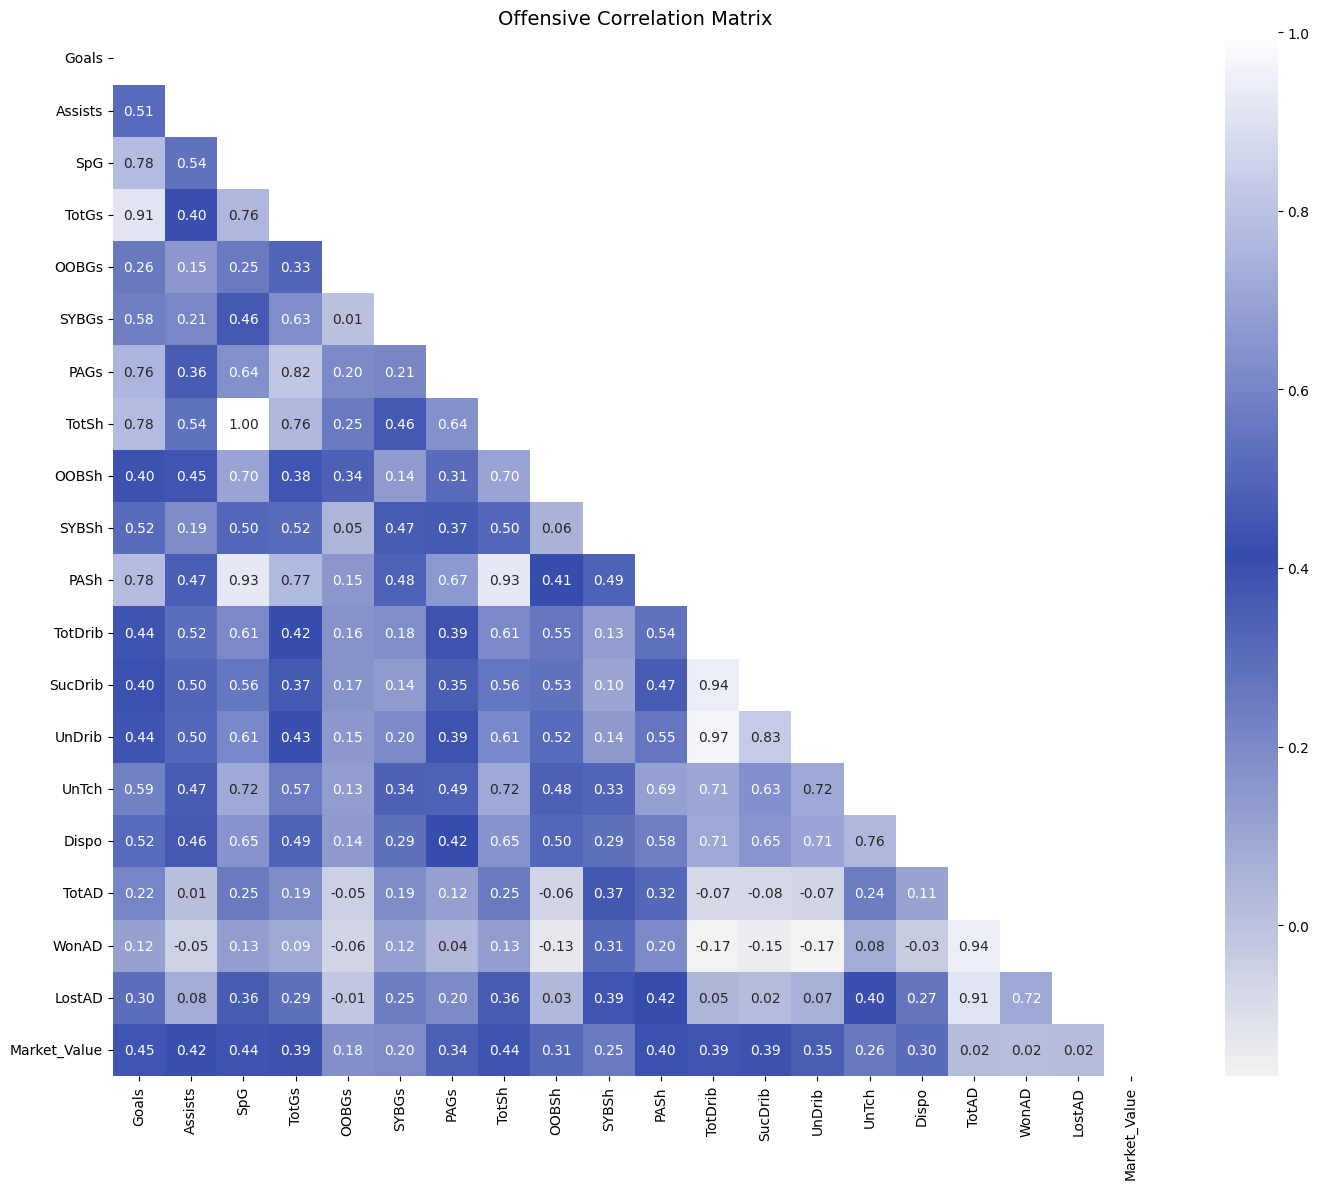

In [369]:
Offensive_cols = [
    "Goals",       # Ghi bàn
    "Assists",     # Kiến tạo
    'SpG',
    
    'TotGs', 'OOBGs', 'SYBGs', 'PAGs',
    "TotSh", "OOBSh", "SYBSh", "PASh",          
    
    "TotDrib", "SucDrib", "UnDrib",
    'UnTch', 'Dispo',
    'TotAD', 'WonAD', 'LostAD',
    "Market_Value"
]


Offensive_df = data_encoded[Offensive_cols]
corr = Offensive_df.corr ()

plt.figure (figsize=(15,12))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Tạo một cmap pastel nhẹ nhàng: Xám nhạt → hồng nhạt → trắng
pastel = LinearSegmentedColormap.from_list("pastel_sang", ["#f2f2f2", "#364cad", "#ffffff"])

sns.heatmap (corr, annot=True, fmt='.2f', cmap=pastel, square=True, mask=mask)
plt.title ("Offensive Correlation Matrix", fontsize=14)
plt.tight_layout ()
plt.show ()

- Đối với những cầu thủ trên mặt trận tấn công. Giá trị cầu thủ có tương quan mạnh với: 
    + Goal (0.45)
    + Assists (0.42)
    + TotSh (0.44)
    + MotM (0.45)

# Descriptive statistics and statistical tests

## Jarque - Bera Test

- Giá trị trung bình (Mean) : là một chỉ số thống kê xác định giá trị trung bình của từng thuộc tính 
- Độ lệch chuẩn (standard deviation) : đo lường mức độ biến thiên hay phân tán so với giá trị trung bình  
    + Phản ánh mức độ nhất quán hoặc giao động trong các chỉ số về chất lượng cầu thủ 
- Kiểm định Jarque-Bera (JB) : được sử đụng để đánh giá tính phân phối của dữ liệu 
- Kiểm định Durbin-Watson (DW) : dùng để phát hiện tự tương quan (autocorrelation)
- Kiểm định t-test : được sử dụng để so sánh giá trị trung bình giữa các nhóm khác nhau

In [371]:
from scipy.stats import jarque_bera, ttest_1samp
from statsmodels.stats.stattools import durbin_watson

# Tạo danh sách lưu kết quả
results = []

for col in data_encoded.columns:
    series = data_encoded[col]

    # JB Test
    jb_stat, jb_p = jarque_bera(series)
    
    # Mean và Std
    mean_val = series.mean()
    std_val = series.std()

    # Format kết quả
    results.append({
        'Feature': col,
        'JB Test (p-value)': f"{jb_stat:.3f} ({'<0.01' if jb_p < 0.01 else ('<0.05' if jb_p < 0.05 else f'{jb_p:.2f}')} )",
        'Mean': f"{mean_val:.2f}",
        'Standard Dev': f"{std_val:.2f}"
    })

# Chuyển sang DataFrame
results_df = pd.DataFrame(results)

# Hiển thị bảng
print(results_df.to_string(index=False))


                 Feature    JB Test (p-value)    Mean Standard Dev
                     Age      55.050 (<0.01 )   26.17         4.43
                  Height      17.369 (<0.01 )  183.22         6.72
            Market_Value   54917.640 (<0.01 )   13.14        18.92
             Months_left      83.942 (<0.01 )   23.44        18.09
               Start_app     158.856 (<0.01 )   13.99         9.90
                 Sub_app     537.518 (<0.01 )    5.30         4.93
                    Mins     141.842 (<0.01 ) 1251.81       839.23
                   Goals   20886.229 (<0.01 )    1.76         3.04
                 Assists    7367.789 (<0.01 )    1.24         1.83
                     SpG    1721.290 (<0.01 )    0.70         0.65
                     PS%   29159.737 (<0.01 )   79.85        11.57
              AerialsWon    3651.986 (<0.01 )    0.84         0.81
                    MotM   18742.487 (<0.01 )    0.64         1.17
                  Rating     105.940 (<0.01 )    6.54         

**KẾT LUẬN**

`Jarque-Bera Test (JB Test)`: 
- Tất cả các features đều không tuân theo phân phối chuẩn

- Đối với các mô hình không cần phân phối chuẩn, như *Decision Tree, Random Forest, XGBoost, LightGBM...*, không cần xử lý thêm

- Đối với các mô hình cần phân phối chuẩn, như *Linear Regression, PCA, Logistic Regression, ...*, cần chuyển hoá (Box-Cox, StandardScaler, MinMaxScaler, log(x+1),...)

`Dustin-Watson Test (DW Test)`:



In [372]:
df = data_encoded.copy ()
df

,Age,Height,Market_Value,Months_left,Start_app,Sub_app,Mins,Goals,Assists,SpG,PS%,AerialsWon,MotM,Rating,TotAD,WonAD,LostAD,CrAss,CorAss,ThrbAss,FreAss,OthAss,TotAss,BlkSh,BlkCr,...,PASav,OOBSav,TotSh,OOBSh,SYBSh,PASh,TotTkl,DribPast,TotAttTkl,Card,League_EPL,League_Laliga,League_Ligue1,League_SerieA,Foot_left,Foot_right,Position_Group_Tiền vệ,Position_Group_Tiền đạo,Continent_Grouped_Europe,Continent_Grouped_Other,Club_Group_Lower Tier,Club_Group_Mid-High Tier,Club_Group_Mid-Tier,Club_Group_Top Tier,Club_Group_Upper Tier
0,22,188,18.0,49.0,19.0,5.0,1619.0,7,2,2.2,70.4,1.5,3,6.84,3.0,1.5,1.5,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,...,0.0,0.0,2.2,0.8,0.1,1.3,0.8,0.4,1.2,2,False,False,False,False,False,True,False,True,True,False,False,True,False,False,False
1,27,186,2.0,37.0,15.0,14.0,1383.0,2,1,1.1,81.9,0.9,0,6.55,1.4,0.9,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,...,0.0,0.0,1.1,0.4,0.1,0.5,1.2,0.8,1.9,1,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False
2,32,181,6.0,13.0,23.0,5.0,1812.0,11,4,1.4,75.6,0.5,2,6.76,1.7,0.5,1.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,...,0.0,0.0,1.4,0.3,0.2,1.0,0.3,0.3,0.5,3,False,False,False,False,False,True,False,True,True,False,True,False,False,False,False
3,27,173,20.0,49.0,15.0,10.0,1295.0,3,3,0.6,91.0,0.1,1,6.68,0.4,0.1,0.3,0.1,0.1,0.0,0.0,0.0,0.1,0.0,0.0,...,0.0,0.0,0.6,0.4,0.0,0.2,0.4,0.3,0.7,2,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False
4,20,188,50.0,49.0,16.0,2.0,1250.0,1,0,0.4,94.1,0.5,0,6.85,0.9,0.5,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,...,0.0,0.0,0.4,0.3,0.0,0.1,1.8,0.5,2.3,2,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,27,180,28.0,1.0,19.0,3.0,1471.0,2,2,1.7,76.6,2.4,0,6.81,4.3,2.4,1.9,0.0,0.0,0.0,0.0,0.1,0.1,0.2,0.0,...,0.0,0.0,1.7,0.5,0.2,1.0,1.0,0.6,1.6,1,False,False,False,True,True,False,False,True,False,True,False,False,False,False,True
2245,25,186,8.0,49.0,3.0,6.0,369.0,2,0,1.0,77.3,0.7,0,6.39,2.2,0.7,1.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.1,0.2,0.7,0.3,0.2,0.6,1,False,False,False,True,False,True,False,True,True,False,False,False,True,False,False
2246,24,187,2.5,13.0,11.0,6.0,946.0,0,4,0.8,71.8,0.9,0,6.49,1.8,0.9,0.9,0.2,0.1,0.0,0.1,0.1,0.2,0.1,0.3,...,0.0,0.0,0.8,0.4,0.1,0.4,0.6,0.2,0.8,0,False,False,False,True,False,True,True,False,True,False,False,False,False,False,False
2247,26,178,25.0,37.0,24.0,1.0,2036.0,10,3,3.7,69.9,2.4,4,7.08,4.6,2.4,2.3,0.0,0.0,0.0,0.0,0.1,0.1,0.1,0.0,...,0.0,0.0,3.7,1.1,0.3,2.3,0.4,0.3,0.8,9,False,False,False,True,False,True,False,True,False,True,False,False,False,False,True


In [403]:
data_encoded = df.copy ()

In [404]:
for col in data_encoded.columns:
    if data_encoded[col].dtype == 'bool':
        data_encoded[col] = data_encoded[col].astype(int)

## ANOVA

In [ ]:
'''
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(score_func=f_regression, k='all')  # Hoặc k=10 nếu bạn chỉ muốn top 10 feature
y = data_encoded['Market_Value']            # Cột target
X = data_encoded.drop(columns=['Market_Value']) 
selector.fit(X, y)

anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F-value': selector.scores_,
    'p-value': selector.pvalues_
})

# Bước 4: Lọc các feature có ý nghĩa thống kê (p < 0.05)
selected_features = anova_results[anova_results['p-value'] < 0.05].sort_values(by='F-value', ascending=False)

# Xem kết quả
print(selected_features)
'''

                     Feature      F-value        p-value
72       Club_Group_Top Tier  3230.809600   0.000000e+00
12                    Rating   728.465277  3.297665e-139
11                      MotM   581.216256  2.092012e-114
6                      Goals   556.548188  4.004074e-110
51                     TotSh   545.886438  2.917222e-108
8                        SpG   545.886438  2.917222e-108
38                      SKPs   525.479406  1.121784e-104
7                    Assists   494.234790   3.896548e-99
36                    TotKPs   432.159684   6.178664e-88
54                      PASh   428.226065   3.231998e-87
27                   SucDrib   411.833500   3.277793e-84
31                     TotGs   409.751203   7.921082e-84
28                   TotDrib   396.092889   2.629663e-81
2                Months_left   329.638762   7.563027e-69
26                    UnDrib   318.765704   8.879109e-67
21                    TotAss   307.591545   1.215470e-64
33                      PAGs   

In [ ]:
'''
selected_features = anova_results[anova_results['p-value'] < 0.05]['Feature'].tolist()
not_selected_features = anova_results[anova_results['p-value'] >= 0.05]['Feature'].tolist()

# In ra danh sách
print("✅ Selected features (p < 0.05):")
print(selected_features)

print("\n🚫 Not selected features (p >= 0.05):")
print(not_selected_features)

X_selected = X[selected_features]
X_selected
'''

✅ Selected features (p < 0.05):
['Age', 'Months_left', 'Start_app', 'Sub_app', 'Mins', 'Goals', 'Assists', 'SpG', 'PS%', 'MotM', 'Rating', 'CrAss', 'CorAss', 'ThrbAss', 'OthAss', 'TotAss', 'BlkPs', 'TotClr', 'UnDrib', 'SucDrib', 'TotDrib', 'Fouled', 'Fouls', 'TotGs', 'SYBGs', 'PAGs', 'OOBGs', 'TotKPs', 'LKPs', 'SKPs', 'COF', 'TotPs', 'InAccLB', 'AccSP', 'InAccSP', 'UnTch', 'Dispo', 'TotSav', 'SYBSav', 'PASav', 'OOBSav', 'TotSh', 'OOBSh', 'SYBSh', 'PASh', 'TotTkl', 'DribPast', 'TotAttTkl', 'Card', 'League_EPL', 'League_Laliga', 'League_Ligue1', 'League_SerieA', 'Position_Group_Tiền đạo', 'Continent_Grouped_Europe', 'Continent_Grouped_Other', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper Tier']

🚫 Not selected features (p >= 0.05):
['Height', 'AerialsWon', 'TotAD', 'WonAD', 'LostAD', 'FreAss', 'BlkSh', 'BlkCr', 'TotInt', 'AccLB', 'Foot_left', 'Foot_right', 'Position_Group_Tiền vệ']


## Variance Inflation Factor (VIF)

In [405]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(X):
    X = add_constant(X)
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    vif_data["VIF"] = vif_data["VIF"].round(2)
    return vif_data.drop(index=0)  # Bỏ intercept ra cho dễ nhìn (nếu cần)

# Ví dụ dùng:
# X là DataFrame chứa các biến độc lập
# X = df[["age", "income", "education", "experience"]]

vif_result = calculate_vif(data_encoded)
print(vif_result.sort_values(by="VIF", ascending=False))


                     feature       VIF
16                     WonAD       inf
53                     TotSh       inf
10                       SpG       inf
12                AerialsWon       inf
42                     TotPs  72446.99
45                     AccSP  55619.73
49                    TotSav   3034.23
44                   InAccLB   1741.07
51                     PASav   1210.91
15                     TotAD    964.02
43                     AccLB    761.53
46                   InAccSP    653.85
30                   TotDrib    487.90
59                 TotAttTkl    456.04
52                    OOBSav    339.80
57                    TotTkl    245.93
17                    LostAD    235.00
28                    UnDrib    176.71
38                    TotKPs    165.07
5                  Start_app    128.23
7                       Mins    122.54
40                      SKPs    114.13
29                   SucDrib    100.97
56                      PASh     87.31
58                  DribP

In [406]:
vif_col_inf = []
for i in range(1, len(vif_result)):
    if (vif_result['VIF'][i]) == np.inf or (vif_result['VIF'][i]) >= 10:
        #print(vif_result['feature'][i])
        vif_col_inf.append(vif_result['feature'][i])
vif_col_inf

['Start_app',
 'Mins',
 'Goals',
 'SpG',
 'AerialsWon',
 'TotAD',
 'WonAD',
 'LostAD',
 'TotAss',
 'UnDrib',
 'SucDrib',
 'TotDrib',
 'TotGs',
 'TotKPs',
 'LKPs',
 'SKPs',
 'TotPs',
 'AccLB',
 'InAccLB',
 'AccSP',
 'InAccSP',
 'TotSav',
 'SYBSav',
 'PASav',
 'OOBSav',
 'TotSh',
 'OOBSh',
 'PASh',
 'TotTkl',
 'DribPast',
 'TotAttTkl']

In [407]:
for col in vif_col_inf:
    if col == 'Goals' or col == 'Mins':
        continue
    else:
        data_encoded.drop(col, axis=1, inplace=True)
data_encoded

,Age,Height,Market_Value,Months_left,Sub_app,Mins,Goals,Assists,PS%,MotM,Rating,CrAss,CorAss,ThrbAss,FreAss,OthAss,BlkSh,BlkCr,BlkPs,TotClr,Fouled,Fouls,SYBGs,PAGs,OOBGs,TotInt,COF,UnTch,Dispo,SYBSh,Card,League_EPL,League_Laliga,League_Ligue1,League_SerieA,Foot_left,Foot_right,Position_Group_Tiền vệ,Position_Group_Tiền đạo,Continent_Grouped_Europe,Continent_Grouped_Other,Club_Group_Lower Tier,Club_Group_Mid-High Tier,Club_Group_Mid-Tier,Club_Group_Top Tier,Club_Group_Upper Tier
0,22,188,18.0,49.0,5.0,1619.0,7,2,70.4,3,6.84,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,0.8,1.2,0.6,0.0,0.2,0.0,0.2,0.2,1.7,1.4,0.1,2,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0
1,27,186,2.0,37.0,14.0,1383.0,2,1,81.9,0,6.55,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.9,0.6,0.3,0.6,0.0,0.1,0.0,0.2,0.1,1.2,0.7,0.1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0
2,32,181,6.0,13.0,5.0,1812.0,11,4,75.6,2,6.76,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.4,0.3,1.2,0.6,0.1,0.3,0.0,0.1,0.3,1.4,0.8,0.2,3,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0
3,27,173,20.0,49.0,10.0,1295.0,3,3,91.0,1,6.68,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.4,0.9,0.3,0.2,0.0,0.0,0.1,0.3,0.0,0.4,0.1,0.0,2,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0
4,20,188,50.0,49.0,2.0,1250.0,1,0,94.1,0,6.85,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.8,0.6,0.5,0.9,0.0,0.0,0.1,0.2,0.0,0.7,0.1,0.0,2,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,27,180,28.0,1.0,3.0,1471.0,2,2,76.6,0,6.81,0.0,0.0,0.0,0.0,0.1,0.2,0.0,0.5,1.1,1.5,1.1,0.0,0.0,0.0,0.3,0.2,1.5,0.6,0.2,1,0,0,0,1,1,0,0,1,0,1,0,0,0,0,1
2245,25,186,8.0,49.0,6.0,369.0,2,0,77.3,0,6.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.2,1.3,1.1,0.0,0.0,0.0,0.1,0.1,1.6,0.7,0.2,1,0,0,0,1,0,1,0,1,1,0,0,0,1,0,0
2246,24,187,2.5,13.0,6.0,946.0,0,4,71.8,0,6.49,0.2,0.1,0.0,0.1,0.1,0.1,0.3,0.2,0.3,0.6,0.5,0.0,0.0,0.0,0.3,0.1,1.4,0.5,0.1,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0
2247,26,178,25.0,37.0,1.0,2036.0,10,3,69.9,4,7.08,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.6,0.8,1.5,1.3,0.3,0.0,0.0,0.2,0.6,1.8,1.0,0.3,9,0,0,0,1,0,1,0,1,0,1,0,0,0,0,1


- VIF = 1 : Không có đa cộng tuyến, biến độc lập không tương quan với các biens khác
- 5 <= VIF <= 10 : Mực đa cộng tuyến cao, cần xem xét lại hoặc kết hợp biến để cải thiện mô hình
- VIF > 10 : Biến có khả năng gây ra những vấn đề nghiêm trọng cho mô hình.

## => Silver data 
- Gold data là data của best model 

In [408]:
data_encoded.to_csv('Silver_data.csv') # Đây là dữ liệu phục vụ cho việc Training

In [316]:
data_lr = data_encoded.copy()
data_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249 entries, 0 to 2248
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2249 non-null   int64  
 1   Height                    2249 non-null   int64  
 2   Market_Value              2249 non-null   float64
 3   Months_left               2249 non-null   float64
 4   Sub_app                   2249 non-null   float64
 5   Mins                      2249 non-null   float64
 6   Goals                     2249 non-null   int64  
 7   Assists                   2249 non-null   int64  
 8   PS%                       2249 non-null   float64
 9   MotM                      2249 non-null   int64  
 10  Rating                    2249 non-null   float64
 11  CrAss                     2249 non-null   float64
 12  CorAss                    2249 non-null   float64
 13  ThrbAss                   2249 non-null   float64
 14  FreAss  

In [318]:
correlation_matrix = data_lr.corr()

print('Các biến có tương quan cao với Foot_right (> 0.8):')
for feature, corr_value in correlation_matrix['Foot_right'].items():
    if feature != 'Foot_right' and abs(corr_value) > 0.8:
        print(f'{feature}: {corr_value:.2f}')

print('Các biến có tương quan cao so với Foot_left (> 0.8) : ')
for f, v in correlation_matrix['Foot_left'].items():
    if f != 'Foot_left' and abs(v) > 0.8:
        print(f'{f}: {v:.2f}')

Các biến có tương quan cao với Foot_right (> 0.8):
Foot_left: -0.92
Các biến có tương quan cao so với Foot_left (> 0.8) : 
Foot_right: -0.92


In [319]:
# Loại bỏ Foot_left và tính lại VIF
#data_lr = data_lr.drop(columns= 'Foot_left')
X = data_lr.drop(columns=['Market_Value'])
vif_result = calculate_vif(X)
print(vif_result.sort_values(by="VIF", ascending=False))

                     feature   VIF
6                      Goals  7.59
35                 Foot_left  7.13
36                Foot_right  7.10
7                    Assists  5.30
19                    TotClr  4.47
27                     UnTch  4.13
38   Position_Group_Tiền đạo  3.69
23                      PAGs  3.62
10                    Rating  3.47
5                       Mins  3.19
28                     Dispo  3.08
16                     BlkSh  2.84
25                    TotInt  2.66
9                       MotM  2.52
15                    OthAss  2.43
44       Club_Group_Top Tier  2.37
22                     SYBGs  2.35
21                     Fouls  2.30
30                      Card  2.26
34             League_SerieA  2.20
31                League_EPL  2.15
37    Position_Group_Tiền vệ  2.13
11                     CrAss  2.10
20                    Fouled  2.05
18                     BlkPs  2.05
39  Continent_Grouped_Europe  2.01
32             League_Laliga  2.01
33             Leagu

In [320]:
# Loại bỏ Foot_left và tính lại VIF
data_lr_temp = data_lr.drop(columns= 'Foot_right')
vif_result = calculate_vif(data_lr_temp)
print(vif_result.sort_values(by="VIF", ascending=False))

                     feature   VIF
7                      Goals  7.61
44       Club_Group_Top Tier  5.36
8                    Assists  5.31
3               Market_Value  5.23
20                    TotClr  4.48
28                     UnTch  4.13
38   Position_Group_Tiền đạo  3.69
24                      PAGs  3.62
11                    Rating  3.49
6                       Mins  3.20
29                     Dispo  3.08
17                     BlkSh  2.84
26                    TotInt  2.66
10                      MotM  2.54
45     Club_Group_Upper Tier  2.53
16                    OthAss  2.43
23                     SYBGs  2.36
22                     Fouls  2.30
31                      Card  2.26
35             League_SerieA  2.19
32                League_EPL  2.15
37    Position_Group_Tiền vệ  2.13
42  Club_Group_Mid-High Tier  2.10
12                     CrAss  2.10
21                    Fouled  2.06
19                     BlkPs  2.05
39  Continent_Grouped_Europe  2.01
33             Leagu

- Việc loại bỏ Foot_left hoặc Foot_right làm cho mô hình thiếu ổn định => giữ lại Foot_left và Foot_right